## **Connect Colab**

In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "xx"
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"] = "xx"

In [3]:
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 11 file(s) under /src/
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/pretrained.py
src/utils/save.py -> /content/src/utils/save.py

 All files saved under /content/src/
Contents of /content/src/:
/content/src/cl_strategies/naive.py
/content/src/config/config.py
/content/src/data/dataset.py
/content/src/data/preprocessing.py
/content/src

## **Download DATASET**

In [4]:
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [5]:
# imports
%run /content/src/imports.py
criterion = nn.CrossEntropyLoss()

Using device: cuda


## **Study Dataset**

  Loaded train: 10,055 rows
  Loaded val  : 1,673 rows
  Loaded test : 1,723 rows
  Total videos  : 13,451
  Total classes : 101

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13451 entries, 0 to 13450
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   clip_name  13451 non-null  object
 1   clip_path  13451 non-null  object
 2   label      13451 non-null  object
dtypes: object(3)
memory usage: 315.4+ KB


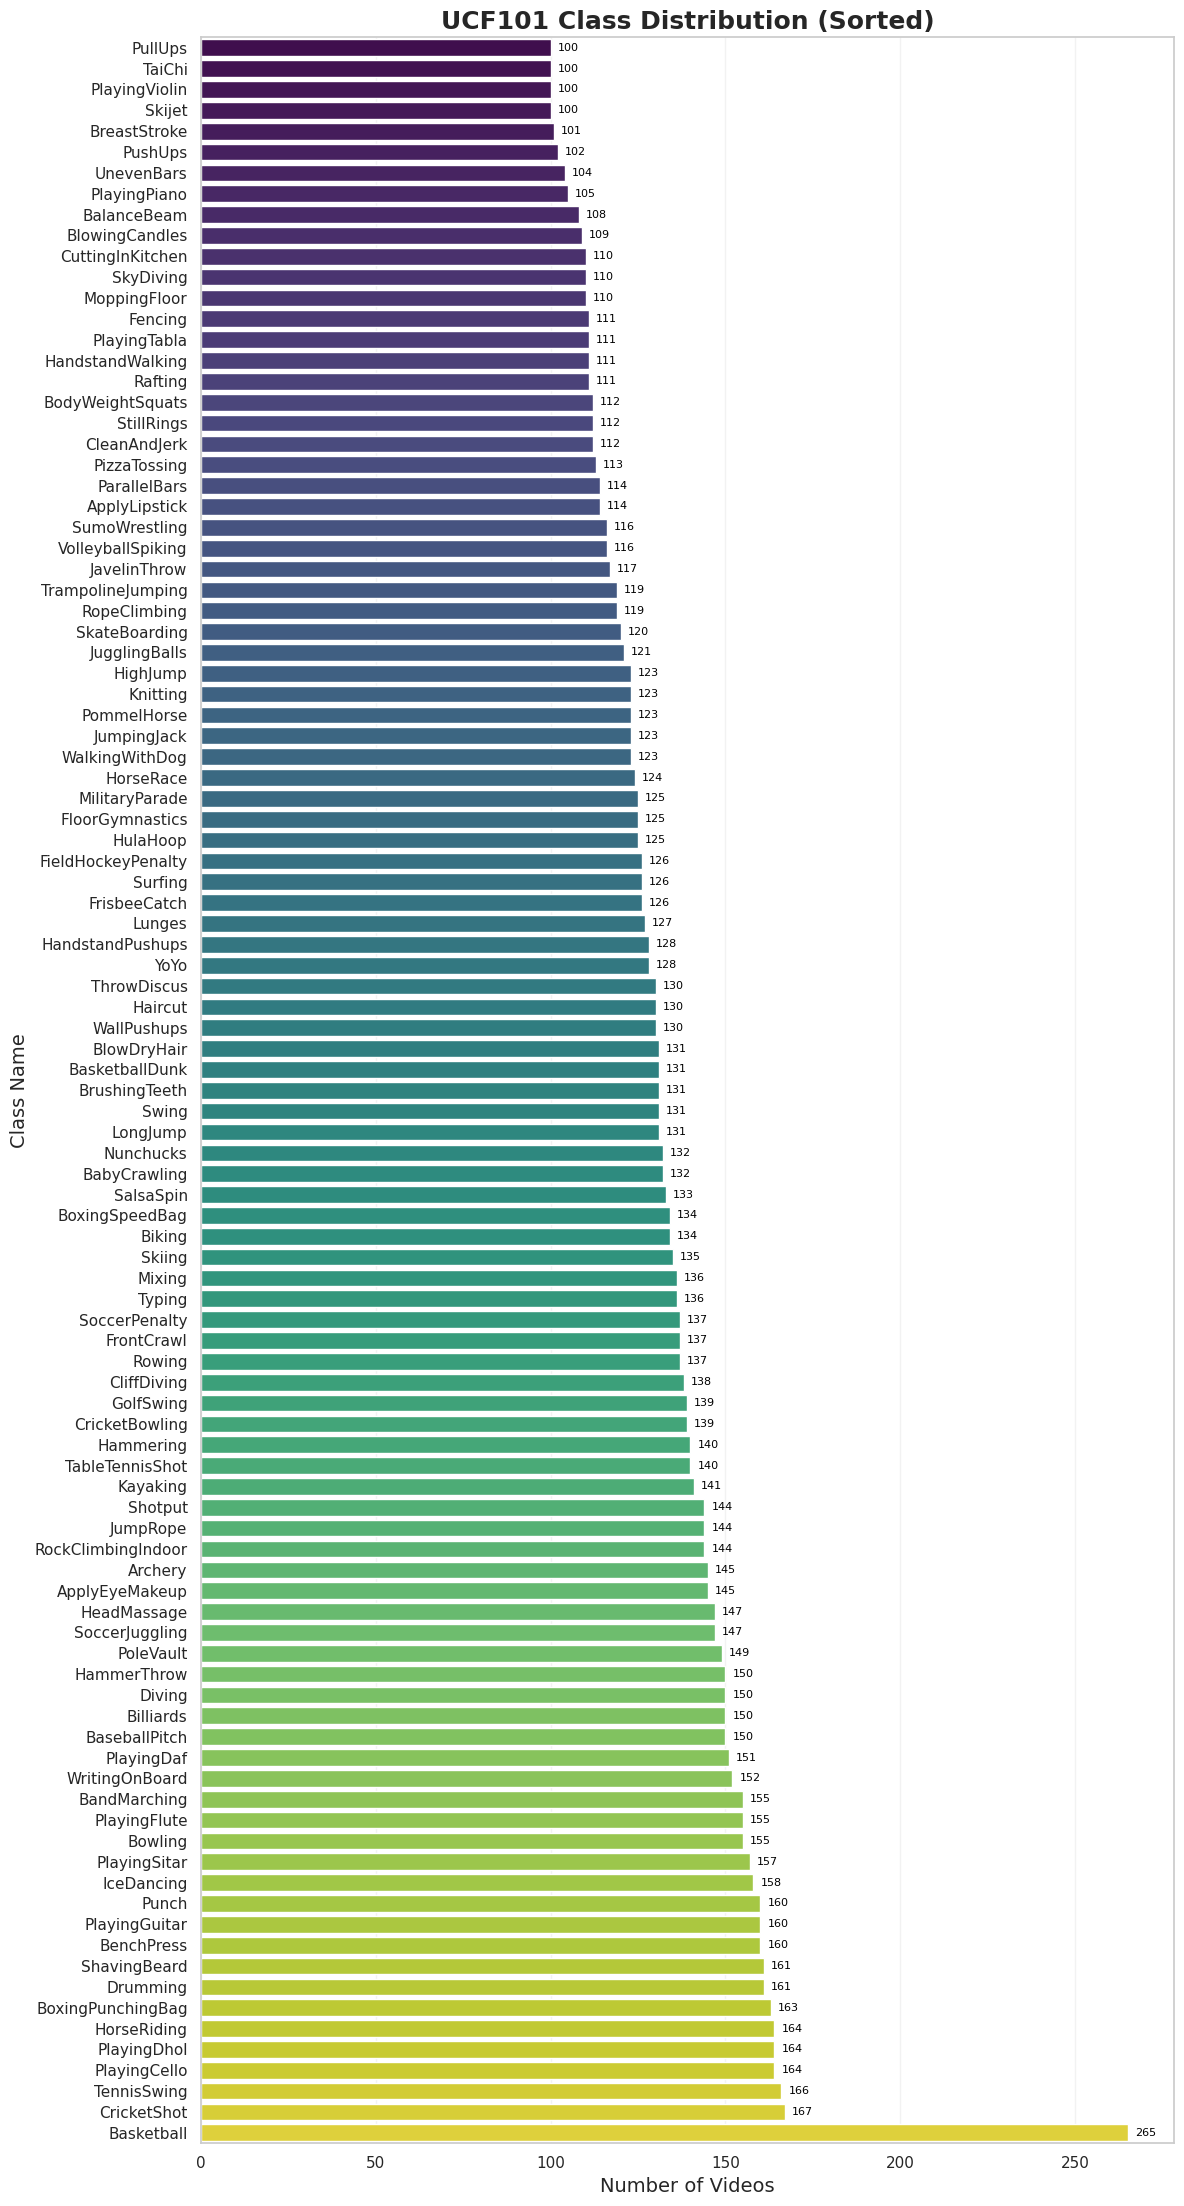

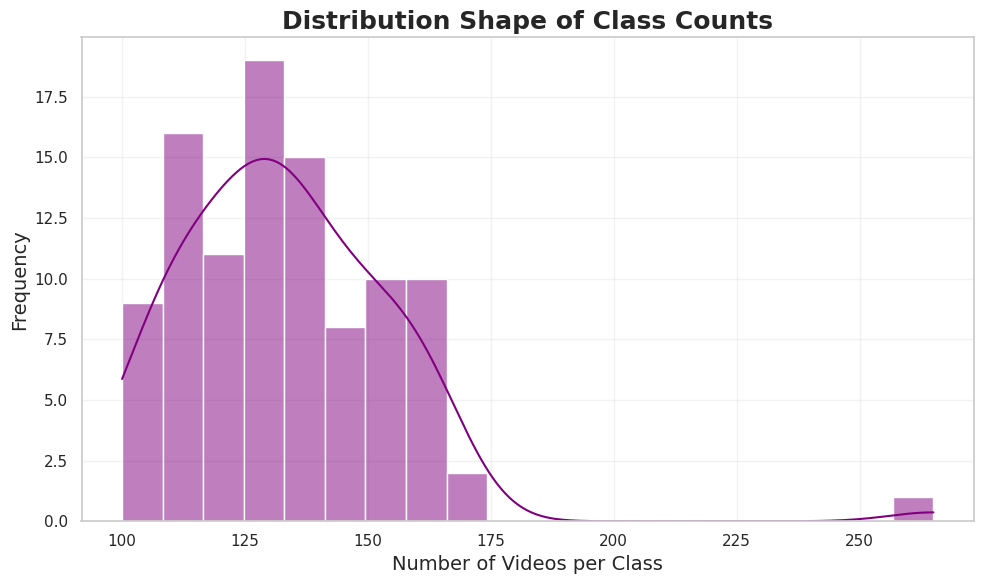

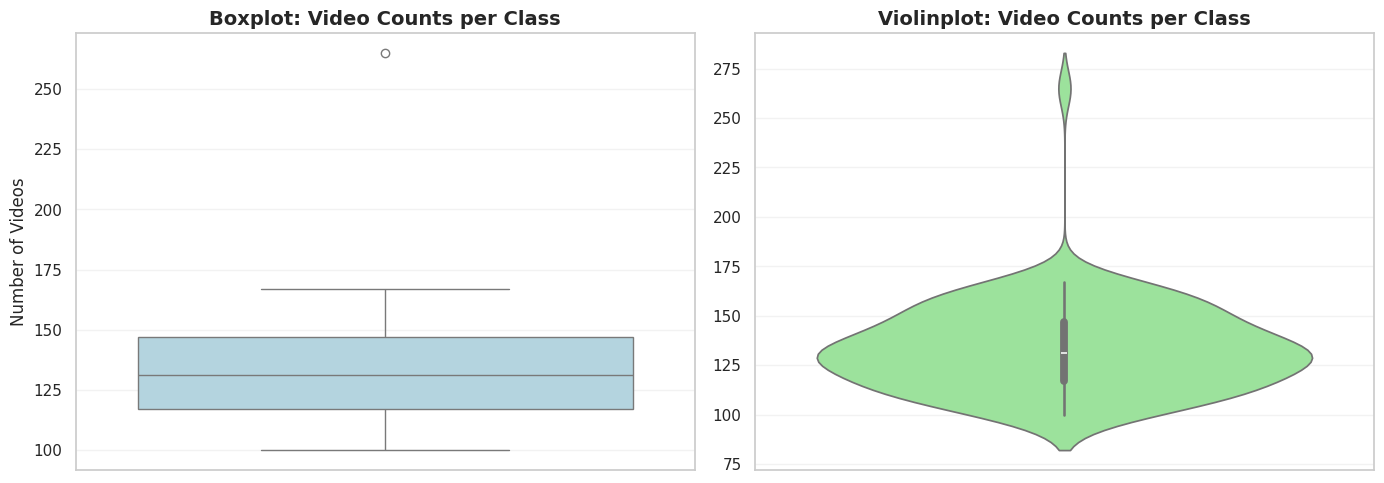


Outlier Classes Detected (IQR Method):
     Class  Count
Basketball    265


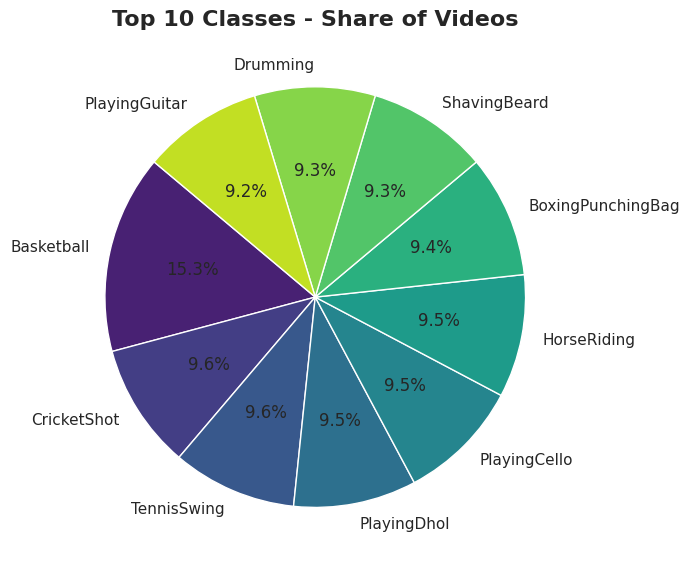


Class Balance Score (std/mean): 0.170
  Dataset is moderately balanced.


In [6]:
study = DatasetStudy()
study.run_all()

## **Preprocess the data**

In [8]:
# specifying the split (ex: "[val]")
preprocess_dataset()

Preprocessing UCF101
  from   : /kaggle/input/ucf101-action-recognition/
  to     : /kaggle/working/ucf101-processed/
  splits : ['train', 'val', 'test']

-> Split: train


  Diving [train]: 100%|██████████| 112/112 [00:13<00:00,  8.20it/s]


-> Split: val


  Diving [val]: 100%|██████████| 19/19 [00:02<00:00,  8.59it/s]


-> Split: test


  Diving [test]: 100%|██████████| 19/19 [00:02<00:00,  7.65it/s]


Done! Processed data saved at: /kaggle/working/ucf101-processed/


## **DataLoaders**

torch.Size([4, 16, 3, 224, 224])
torch.Size([4])


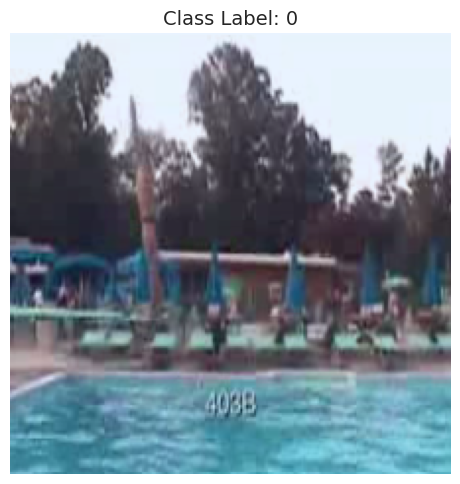

In [9]:
# datasets and loaders
CLASSES_LIST = SELECTED_CLASSES
num_classes  = len(CLASSES_LIST)

train_dataset = UCF101Clips(OUTPUT_ROOT, split="train")
val_dataset   = UCF101Clips(OUTPUT_ROOT, split="val")
test_dataset  = UCF101Clips(OUTPUT_ROOT, split="test")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# check and visualize
for clips, labels in train_loader:
    print(clips.shape)   # [B, T, C, H, W]
    print(labels.shape)  # [B]
    UCF101Clips.show_frame(clips, labels)
    break

In [10]:
print(len(SELECTED_CLASSES))

10


## **RESNET18 + LSTM**

In [11]:
# model
model = ResNet18LSTM().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


In [12]:
summary(model, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet18LSTM                                  [1, 10]                   --
├─Sequential: 1-1                             [16, 512, 1, 1]           --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 64, 56, 56]          --
│    │    └─BasicBlock: 3-1                   [16, 64, 56, 56]          (73,984)
│    │    └─BasicBlock: 3-2                   [16, 64, 56, 56]          (73,984)
│    └─Sequential: 2-6                        [16, 128, 28, 28]         --
│    │    └─BasicBlock: 3-3                   [16, 128, 28, 28]         (230,144)
│    │    └─BasicBlock: 3-4                   [16, 128, 28, 28]     

In [13]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [14]:
results = fine_tune_model(
    model,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device=device,
    task_offset=0,           # no offset -> standard training on labels 0–9
    task_name="base",
    save_flag=False,
)


Fine-tuning 'base'  |  offset=0  |  epochs=10


  [base] E1/10: 100%|██████████| 249/249 [00:40<00:00,  6.09it/s]


  Epoch   1: Train Loss=1.1039 Acc=0.7254 | Val Loss=0.2594 Acc=0.9333


  [base] E2/10: 100%|██████████| 249/249 [00:37<00:00,  6.65it/s]


  Epoch   2: Train Loss=0.3656 Acc=0.9165 | Val Loss=0.1663 Acc=0.9576


...

  Epoch   8: Train Loss=0.0889 Acc=0.9809 | Val Loss=0.1731 Acc=0.9636


  [base] E9/10: 100%|██████████| 249/249 [00:30<00:00,  8.14it/s]


  Epoch   9: Train Loss=0.1200 Acc=0.9698 | Val Loss=0.1160 Acc=0.9697


  [base] E10/10: 100%|██████████| 249/249 [00:29<00:00,  8.33it/s]


  Epoch  10: Train Loss=0.0653 Acc=0.9899 | Val Loss=0.1587 Acc=0.9576


In [15]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9591


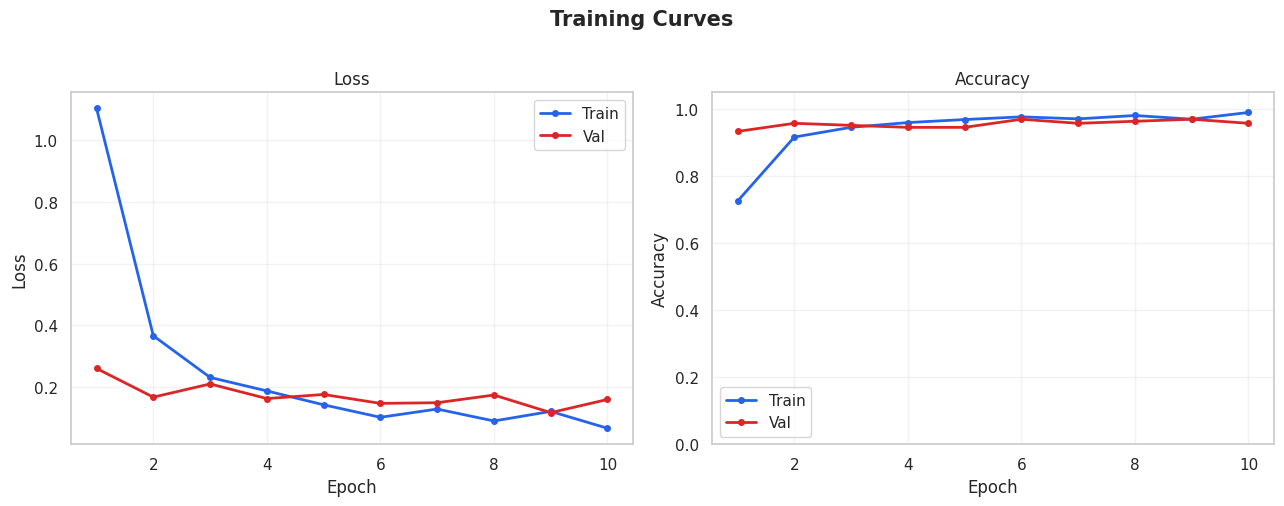

In [16]:
# plot results
plot_training_results(results)

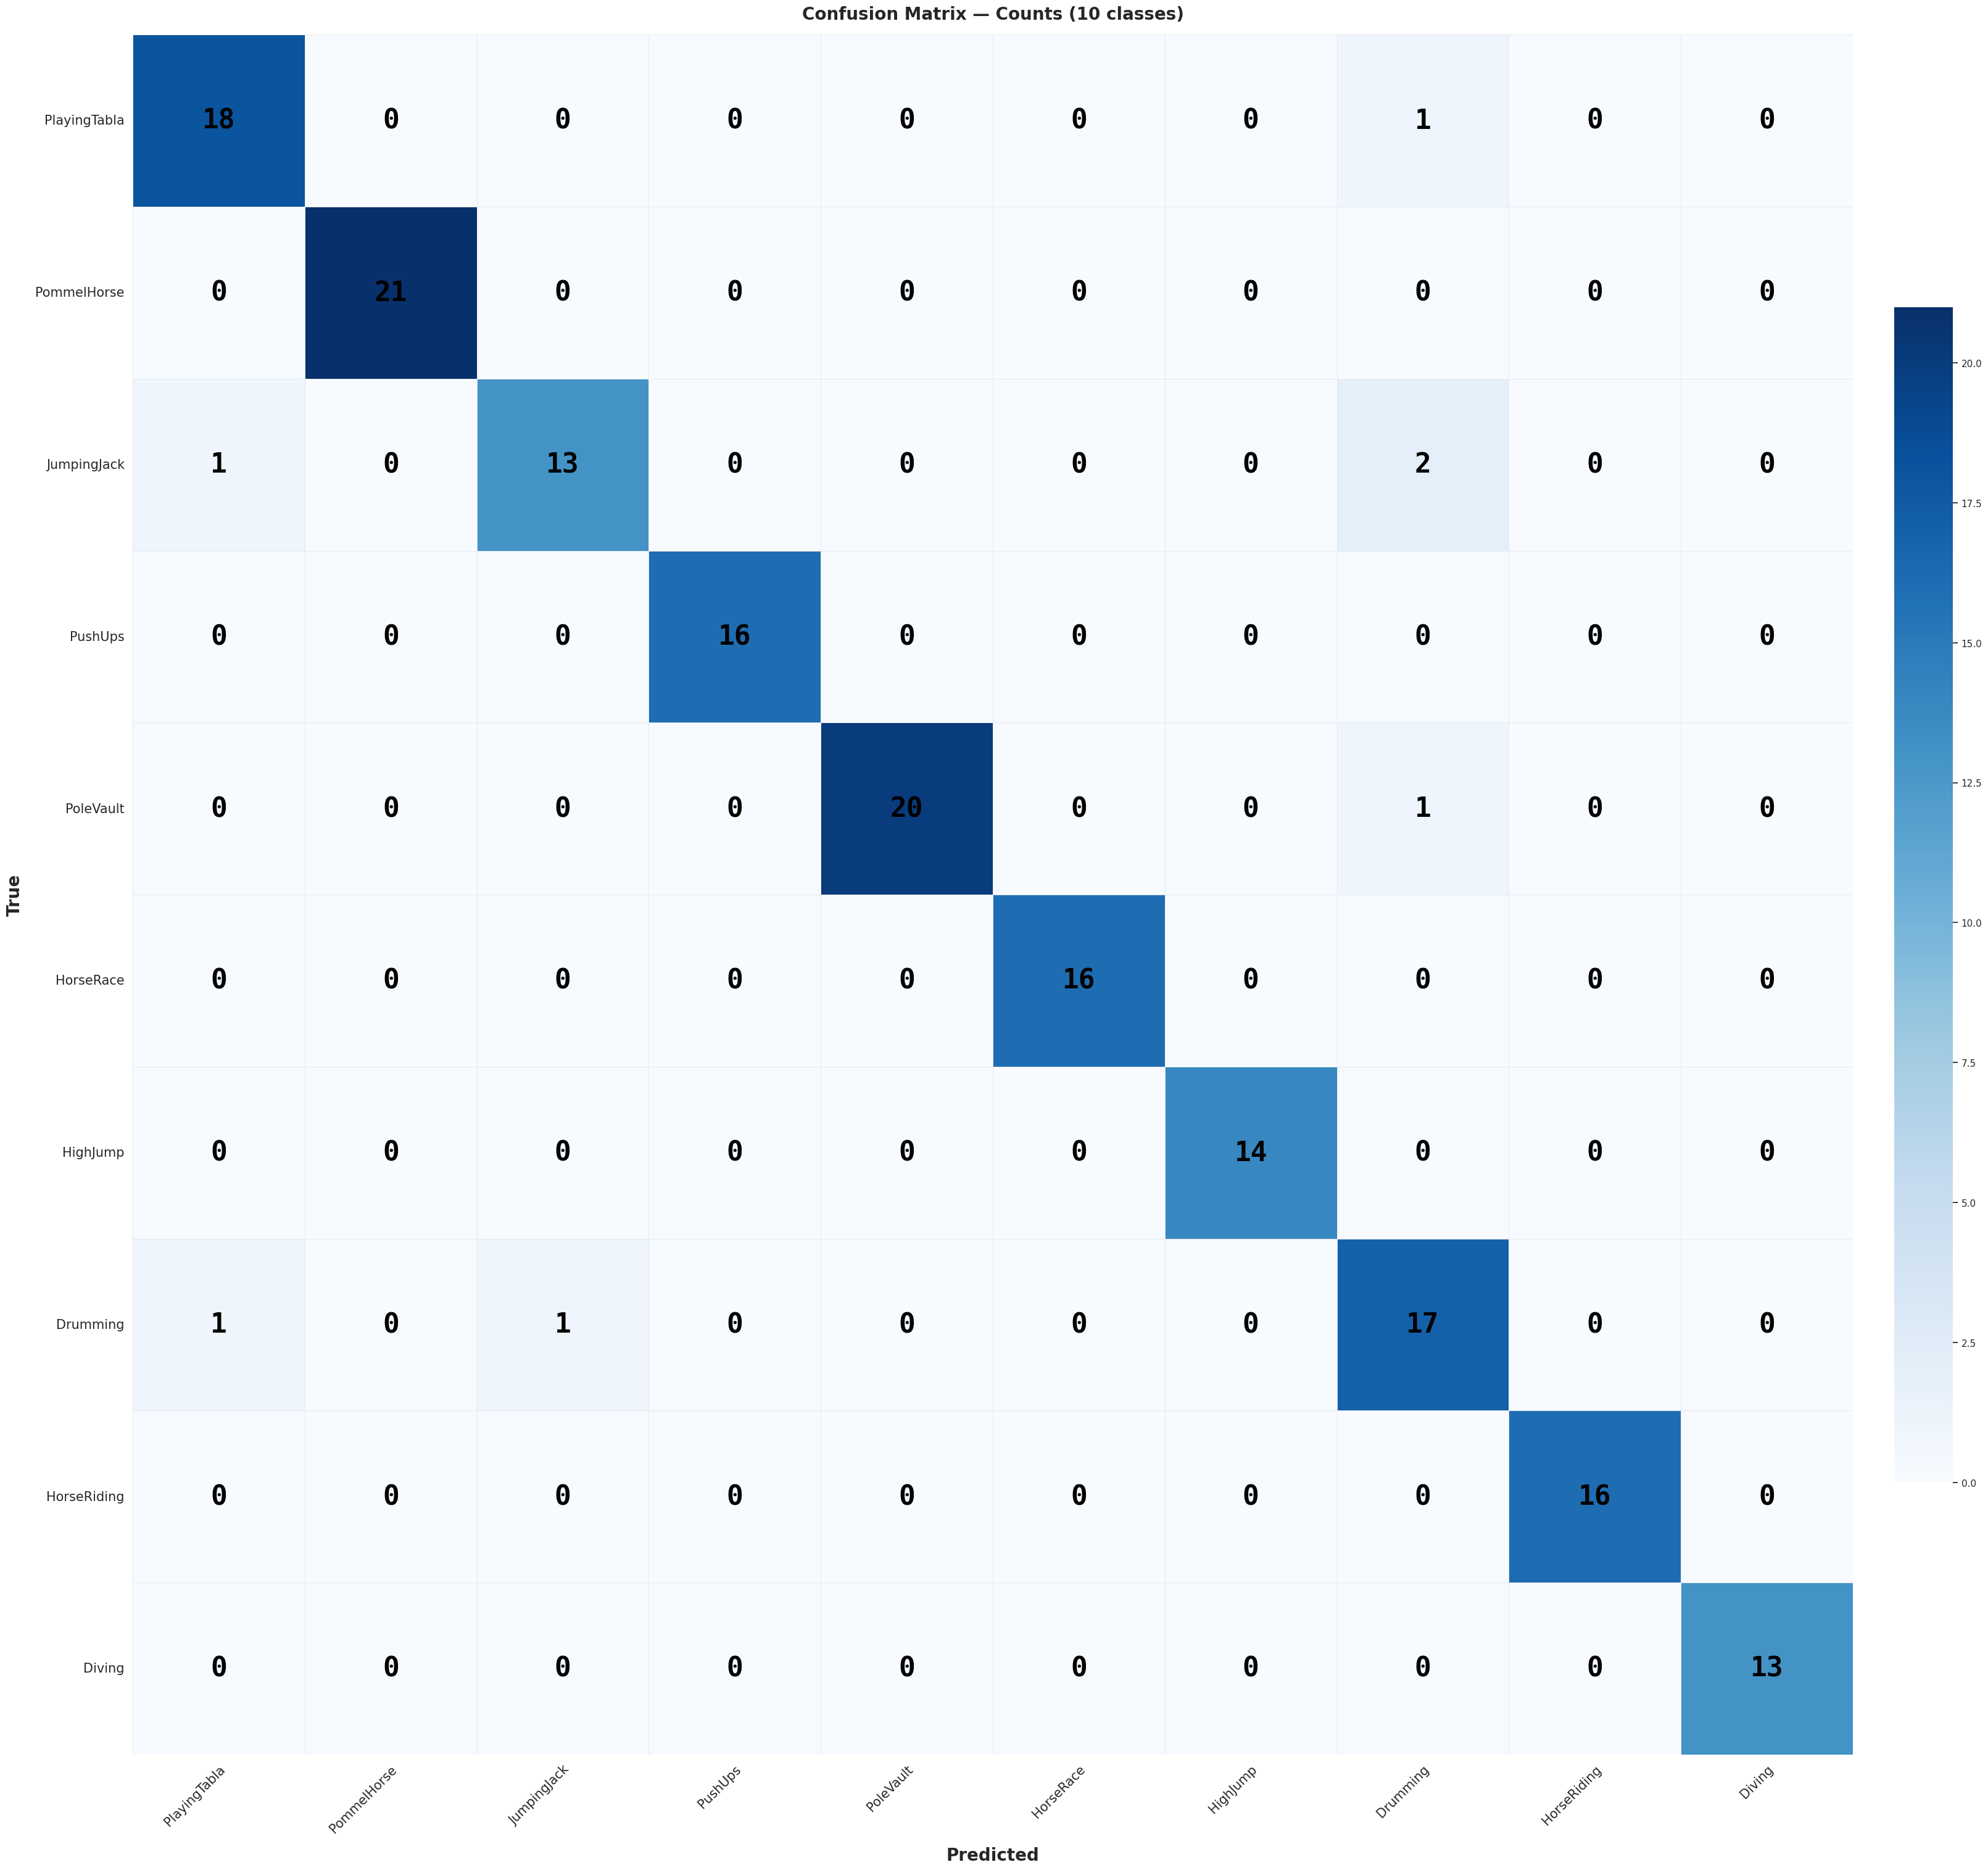

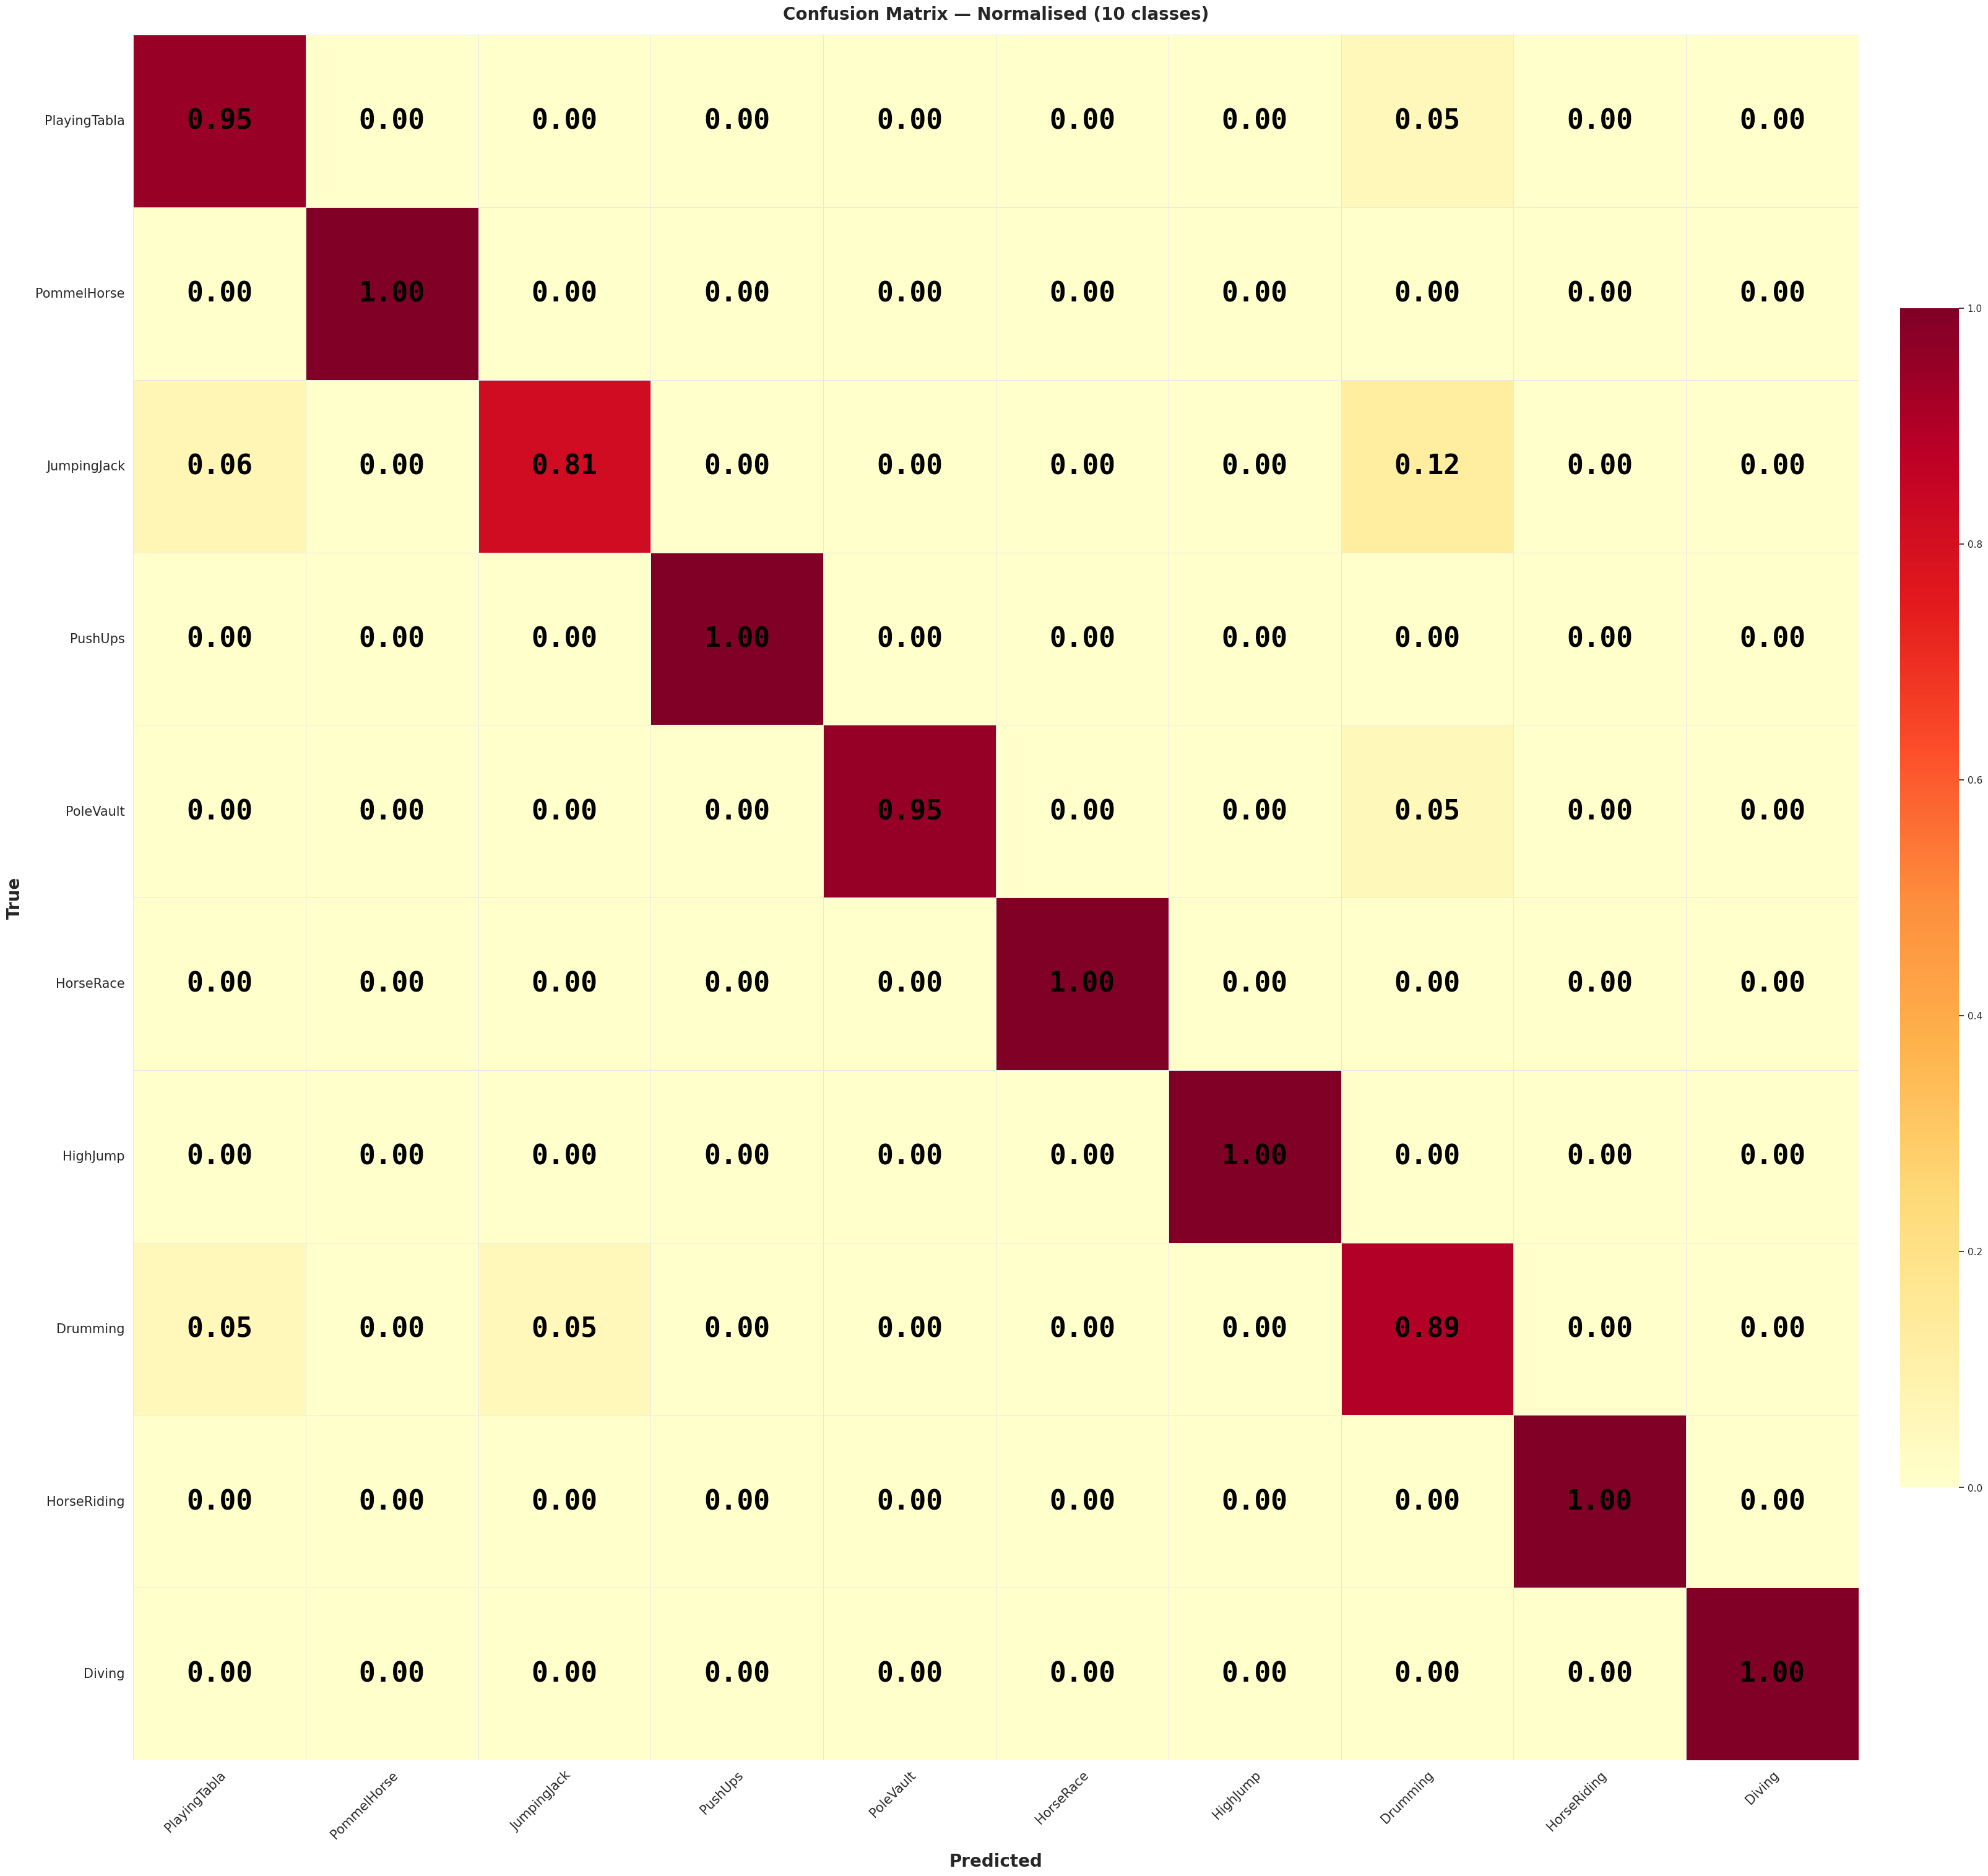

In [17]:
# plot cm
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)

In [18]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9591
  Precision : 0.9610
  Recall    : 0.9591
  F1-Score  : 0.9593

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       0.90      0.95      0.92        19
 PommelHorse       1.00      1.00      1.00        21
 JumpingJack       0.93      0.81      0.87        16
     PushUps       1.00      1.00      1.00        16
   PoleVault       1.00      0.95      0.98        21
   HorseRace       1.00      1.00      1.00        16
    HighJump       1.00      1.00      1.00        14
    Drumming       0.81      0.89      0.85        19
 HorseRiding       1.00      1.00      1.00        16
      Diving       1.00      1.00      1.00        13

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171

TOP 5 BEST CLASSES (F1)
  1. Diving                   : 1.0000
  2. HorseRiding        

## **RESNET50 + LSTM**

In [19]:
model_ResNet50 = ResNet50LSTM().to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


In [20]:
summary(model_ResNet50, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet50LSTM                                  [1, 10]                   --
├─Sequential: 1-1                             [16, 2048, 1, 1]          --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 256, 56, 56]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 56, 56]         (75,008)
│    │    └─Bottleneck: 3-2                   [16, 256, 56, 56]         (70,400)
│    │    └─Bottleneck: 3-3                   [16, 256, 56, 56]         (70,400)
│    └─Sequential: 2-6                        [16, 512, 28, 28]         --
│    │    └─Bottleneck: 3-4                   [16, 512, 28, 28]      

In [21]:
optimizer = optim.Adam(model_ResNet50.parameters(), lr=1e-4)

#### **New folders on drive**

In [22]:
# path
base_path = '/content/drive/MyDrive/apai/resnet50'

# folders
folders = ['models', 'features']

# create folders
for folder in folders:
    path = os.path.join(base_path, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/apai/resnet50/models
Created: /content/drive/MyDrive/apai/resnet50/features


In [23]:
# fine tune
results = fine_tune_model(
    model_ResNet50,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device=device,
    task_offset=0,           # no offset -> standard training on labels 0–9
    task_name="base",
    save_flag=True,
    save_path='/content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth'
)


Fine-tuning 'base'  |  offset=0  |  epochs=10


  [base] E1/10: 100%|██████████| 249/249 [01:17<00:00,  3.20it/s]


  Epoch   1: Train Loss=1.1436 Acc=0.6529 | Val Loss=0.2472 Acc=0.9333
Saved best model -> /content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth  (Val Acc=0.9333)


  [base] E2/10: 100%|██████████| 249/249 [01:17<00:00,  3.22it/s]


  Epoch   2: Train Loss=0.2785 Acc=0.9256 | Val Loss=0.2206 Acc=0.9455
Saved best model -> /content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth  (Val Acc=0.9455)


...

  Epoch   8: Train Loss=0.0363 Acc=0.9879 | Val Loss=0.2066 Acc=0.9515


  [base] E9/10: 100%|██████████| 249/249 [01:16<00:00,  3.24it/s]


  Epoch   9: Train Loss=0.0126 Acc=0.9970 | Val Loss=0.1984 Acc=0.9636


  [base] E10/10: 100%|██████████| 249/249 [01:16<00:00,  3.25it/s]


  Epoch  10: Train Loss=0.0244 Acc=0.9920 | Val Loss=0.1211 Acc=0.9697


### **UPLOAD BEST SAVED**

In [24]:
model_path = '/content/drive/MyDrive/apai/resnet50/models/ResNet50_10C.pth'

# model for feature extraction
model_ResNet50 = ResNet50LSTM(hidden_size=256, num_classes=10).to(device)
checkpoint = torch.load(model_path, map_location=device)
model_ResNet50.load_state_dict(checkpoint)

<All keys matched successfully>

In [25]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model_ResNet50, test_loader, device=device)

Test Accuracy: 0.9532


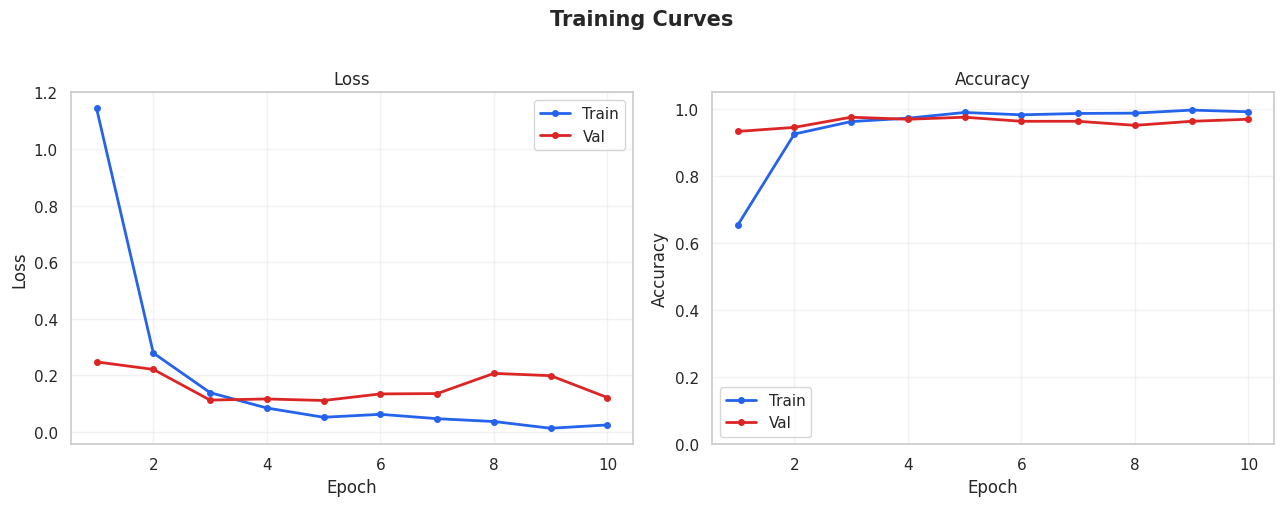

In [26]:
# plot results
plot_training_results(results)

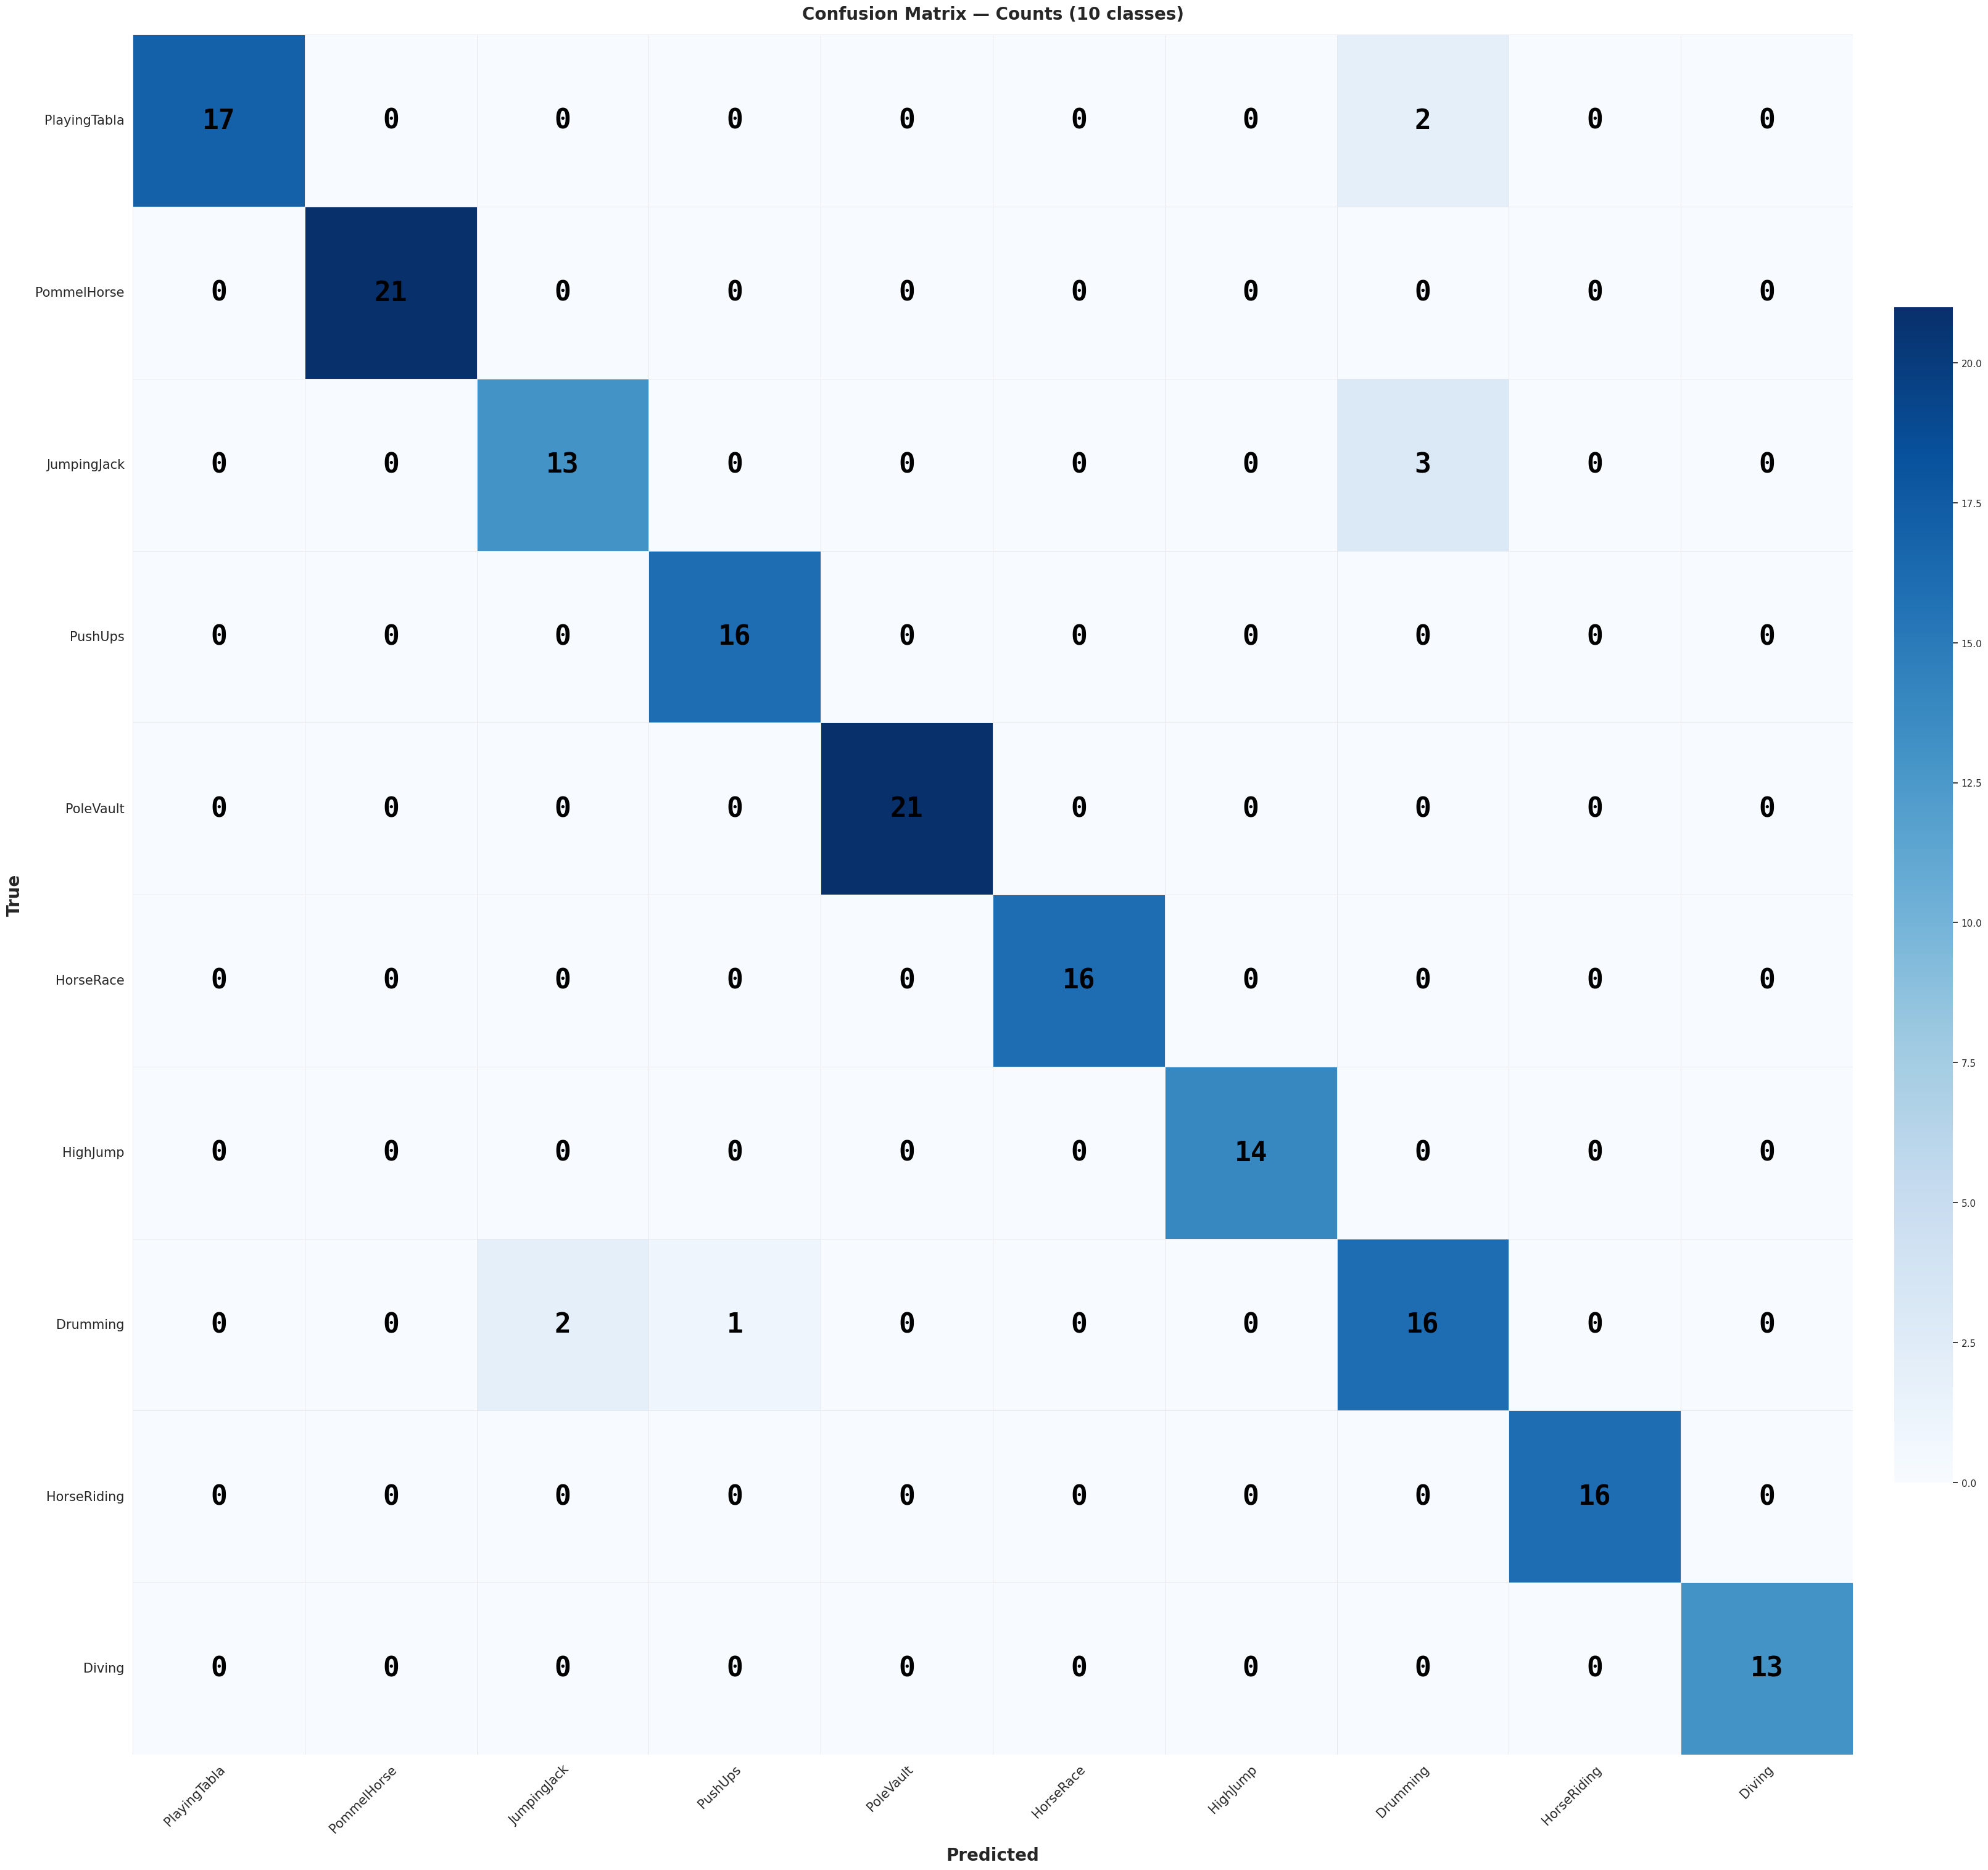

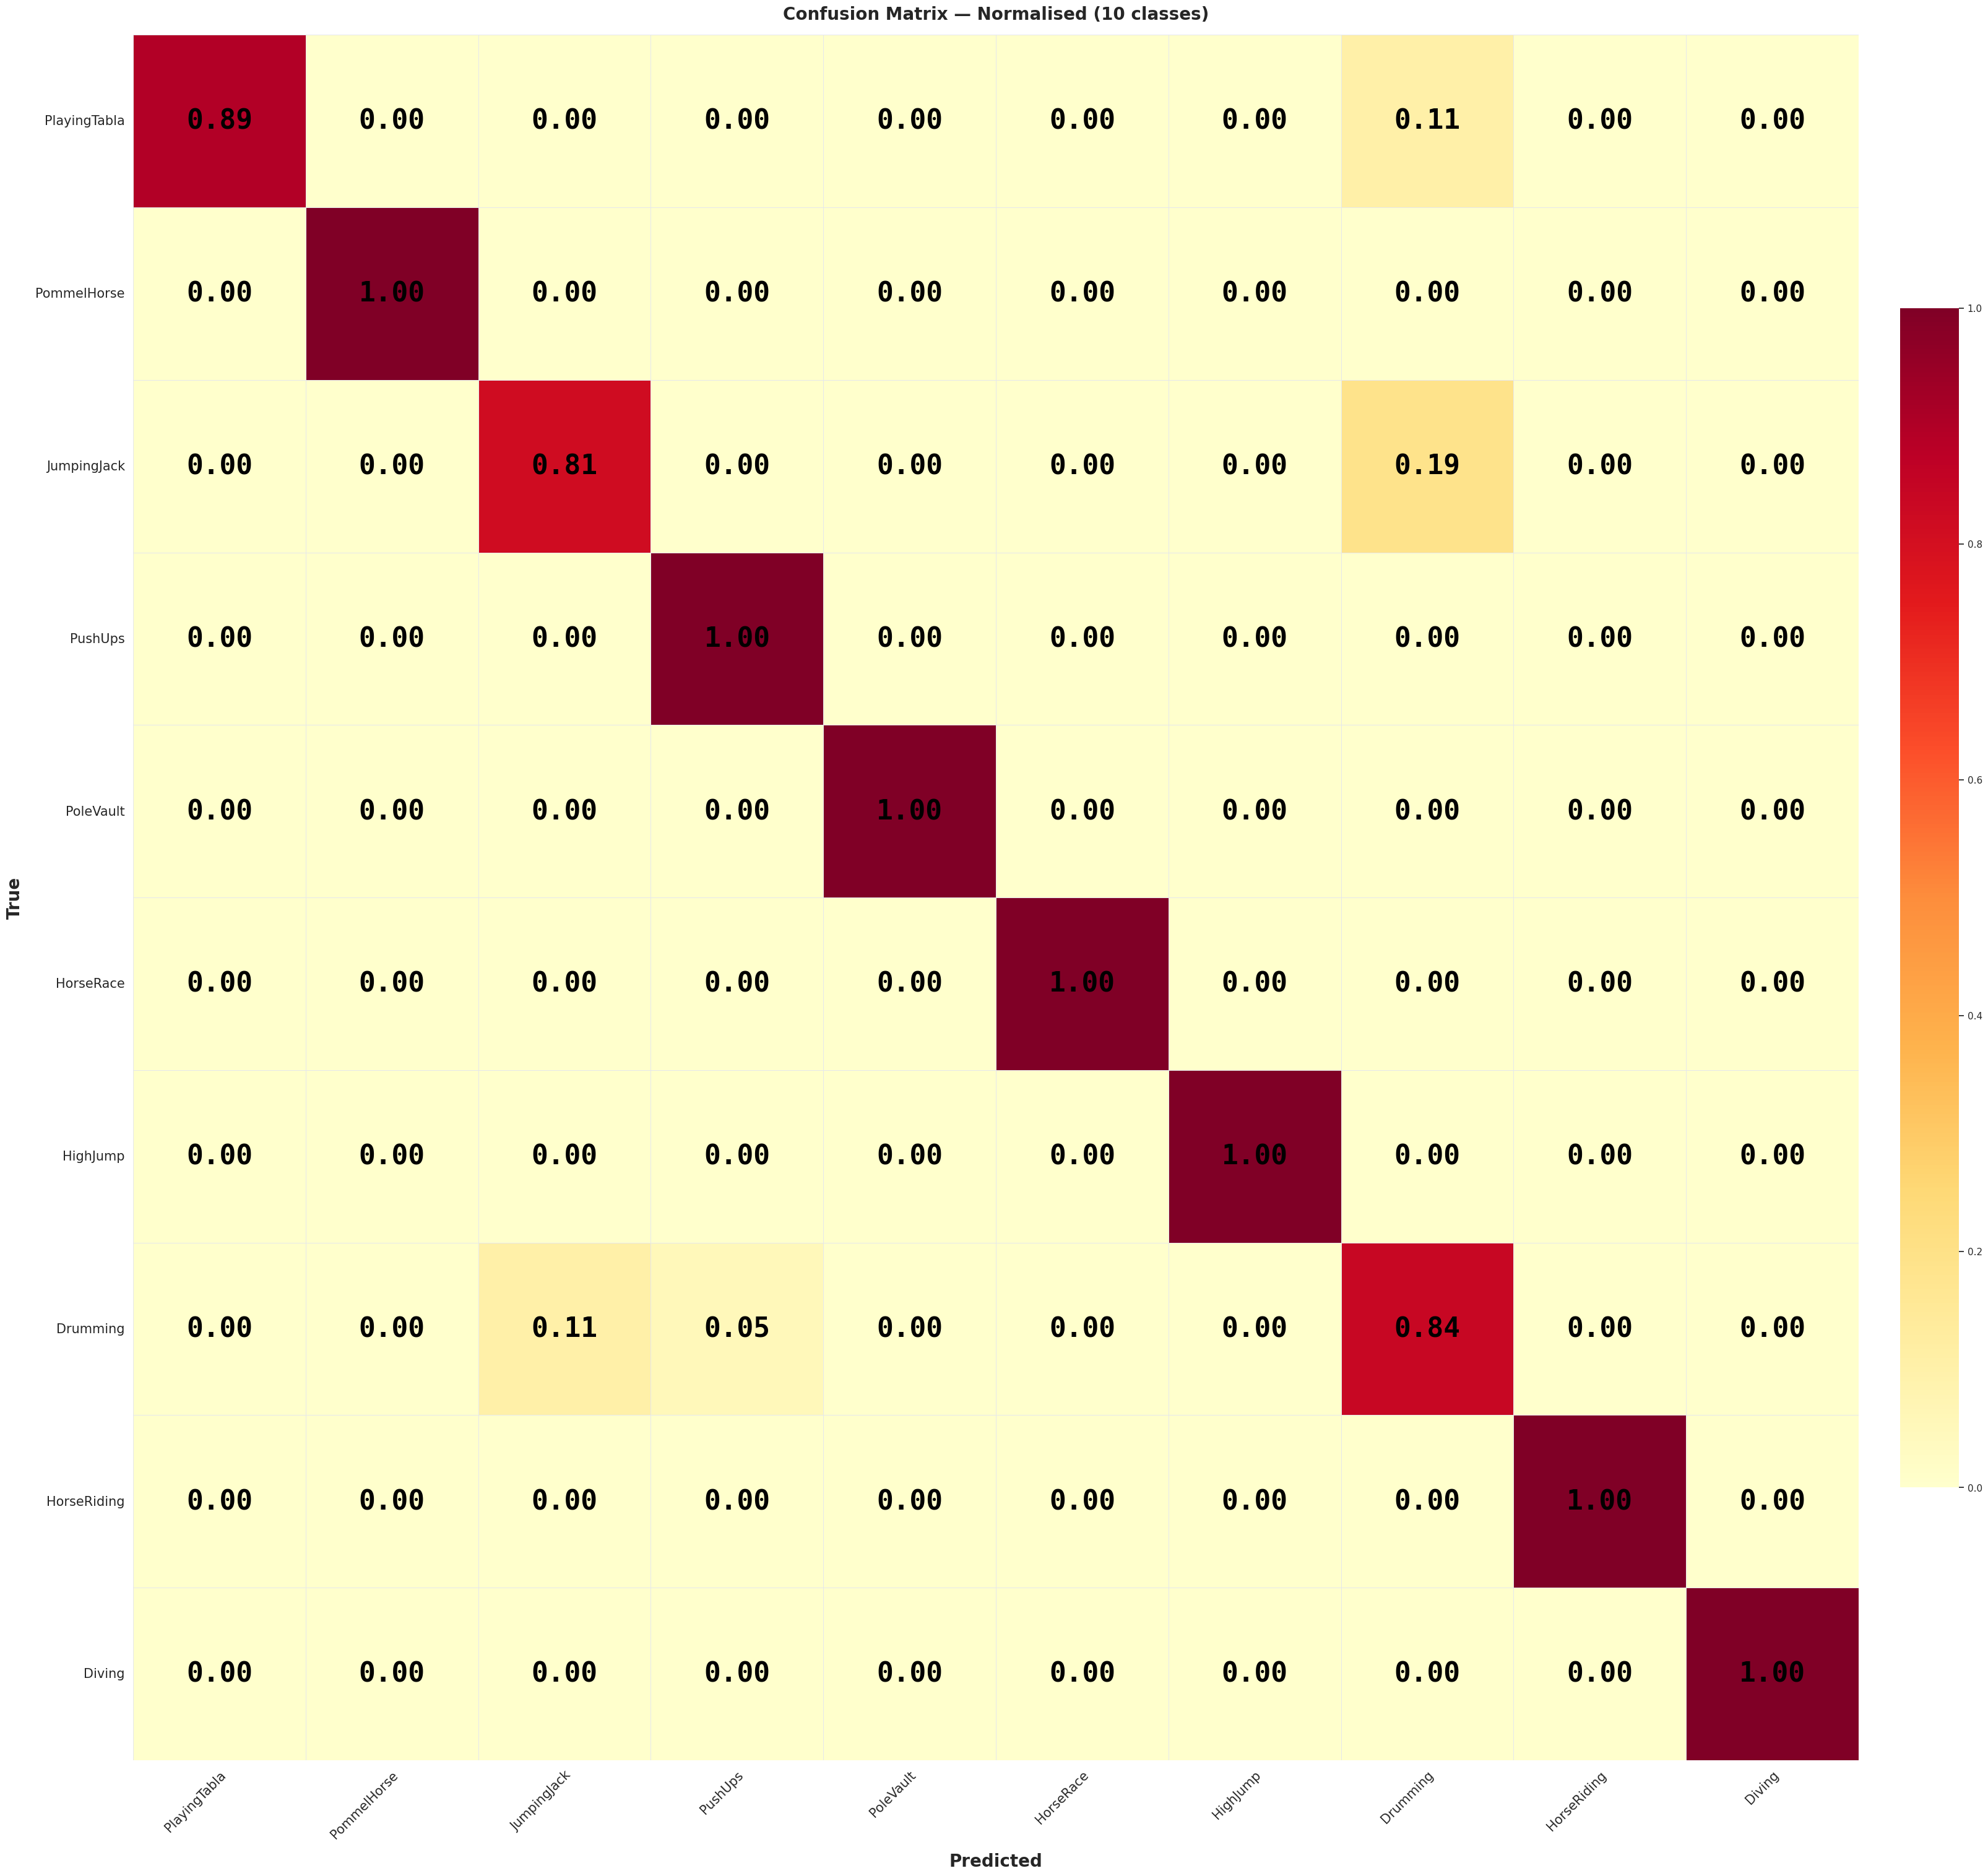

In [27]:
# plot cm
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)

In [28]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9532
  Precision : 0.9556
  Recall    : 0.9532
  F1-Score  : 0.9537

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      0.89      0.94        19
 PommelHorse       1.00      1.00      1.00        21
 JumpingJack       0.87      0.81      0.84        16
     PushUps       0.94      1.00      0.97        16
   PoleVault       1.00      1.00      1.00        21
   HorseRace       1.00      1.00      1.00        16
    HighJump       1.00      1.00      1.00        14
    Drumming       0.76      0.84      0.80        19
 HorseRiding       1.00      1.00      1.00        16
      Diving       1.00      1.00      1.00        13

    accuracy                           0.95       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.95      0.95       171

TOP 5 BEST CLASSES (F1)
  1. Diving                   : 1.0000
  2. HorseRiding        

## **DenseNet121 + LSTM**

In [29]:
model = DenseNet121LSTM().to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 140MB/s] 


In [30]:
summary(model, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet121LSTM                          [1, 10]                   --
├─Sequential: 1-1                        [16, 1024, 7, 7]          --
│    └─Conv2d: 2-1                       [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                  [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                         [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [16, 64, 56, 56]          --
│    └─_DenseBlock: 2-5                  [16, 256, 56, 56]         --
│    │    └─_DenseLayer: 3-1             [16, 32, 56, 56]          (45,440)
│    │    └─_DenseLayer: 3-2             [16, 32, 56, 56]          (49,600)
│    │    └─_DenseLayer: 3-3             [16, 32, 56, 56]          (53,760)
│    │    └─_DenseLayer: 3-4             [16, 32, 56, 56]          (57,920)
│    │    └─_DenseLayer: 3-5             [16, 32, 56, 56]          (62,080)
│    │    └─_DenseLayer: 3-6             [16, 3

In [31]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [32]:
results = fine_tune_model(
    model,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device=device,
    task_offset=0,           # no offset -> standard training on labels 0–9
    task_name="base",
    save_flag=False,
)


Fine-tuning 'base'  |  offset=0  |  epochs=10


  [base] E1/10: 100%|██████████| 249/249 [01:06<00:00,  3.72it/s]


  Epoch   1: Train Loss=1.2875 Acc=0.6630 | Val Loss=0.3777 Acc=0.9515


  [base] E2/10: 100%|██████████| 249/249 [01:07<00:00,  3.71it/s]


  Epoch   2: Train Loss=0.4036 Acc=0.9054 | Val Loss=0.1765 Acc=0.9636


...

  Epoch   8: Train Loss=0.1061 Acc=0.9738 | Val Loss=0.1138 Acc=0.9576


  [base] E9/10: 100%|██████████| 249/249 [01:06<00:00,  3.75it/s]


  Epoch   9: Train Loss=0.0850 Acc=0.9789 | Val Loss=0.1158 Acc=0.9636


  [base] E10/10: 100%|██████████| 249/249 [01:06<00:00,  3.72it/s]


  Epoch  10: Train Loss=0.0763 Acc=0.9789 | Val Loss=0.1352 Acc=0.9636


In [33]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9649


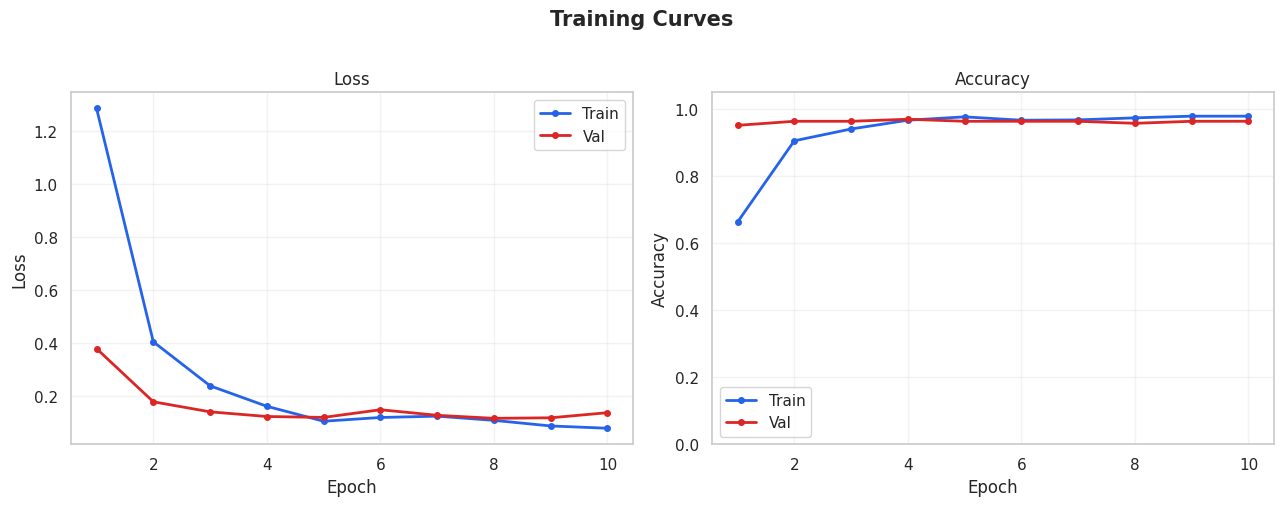

In [34]:
# plot results
plot_training_results(results)

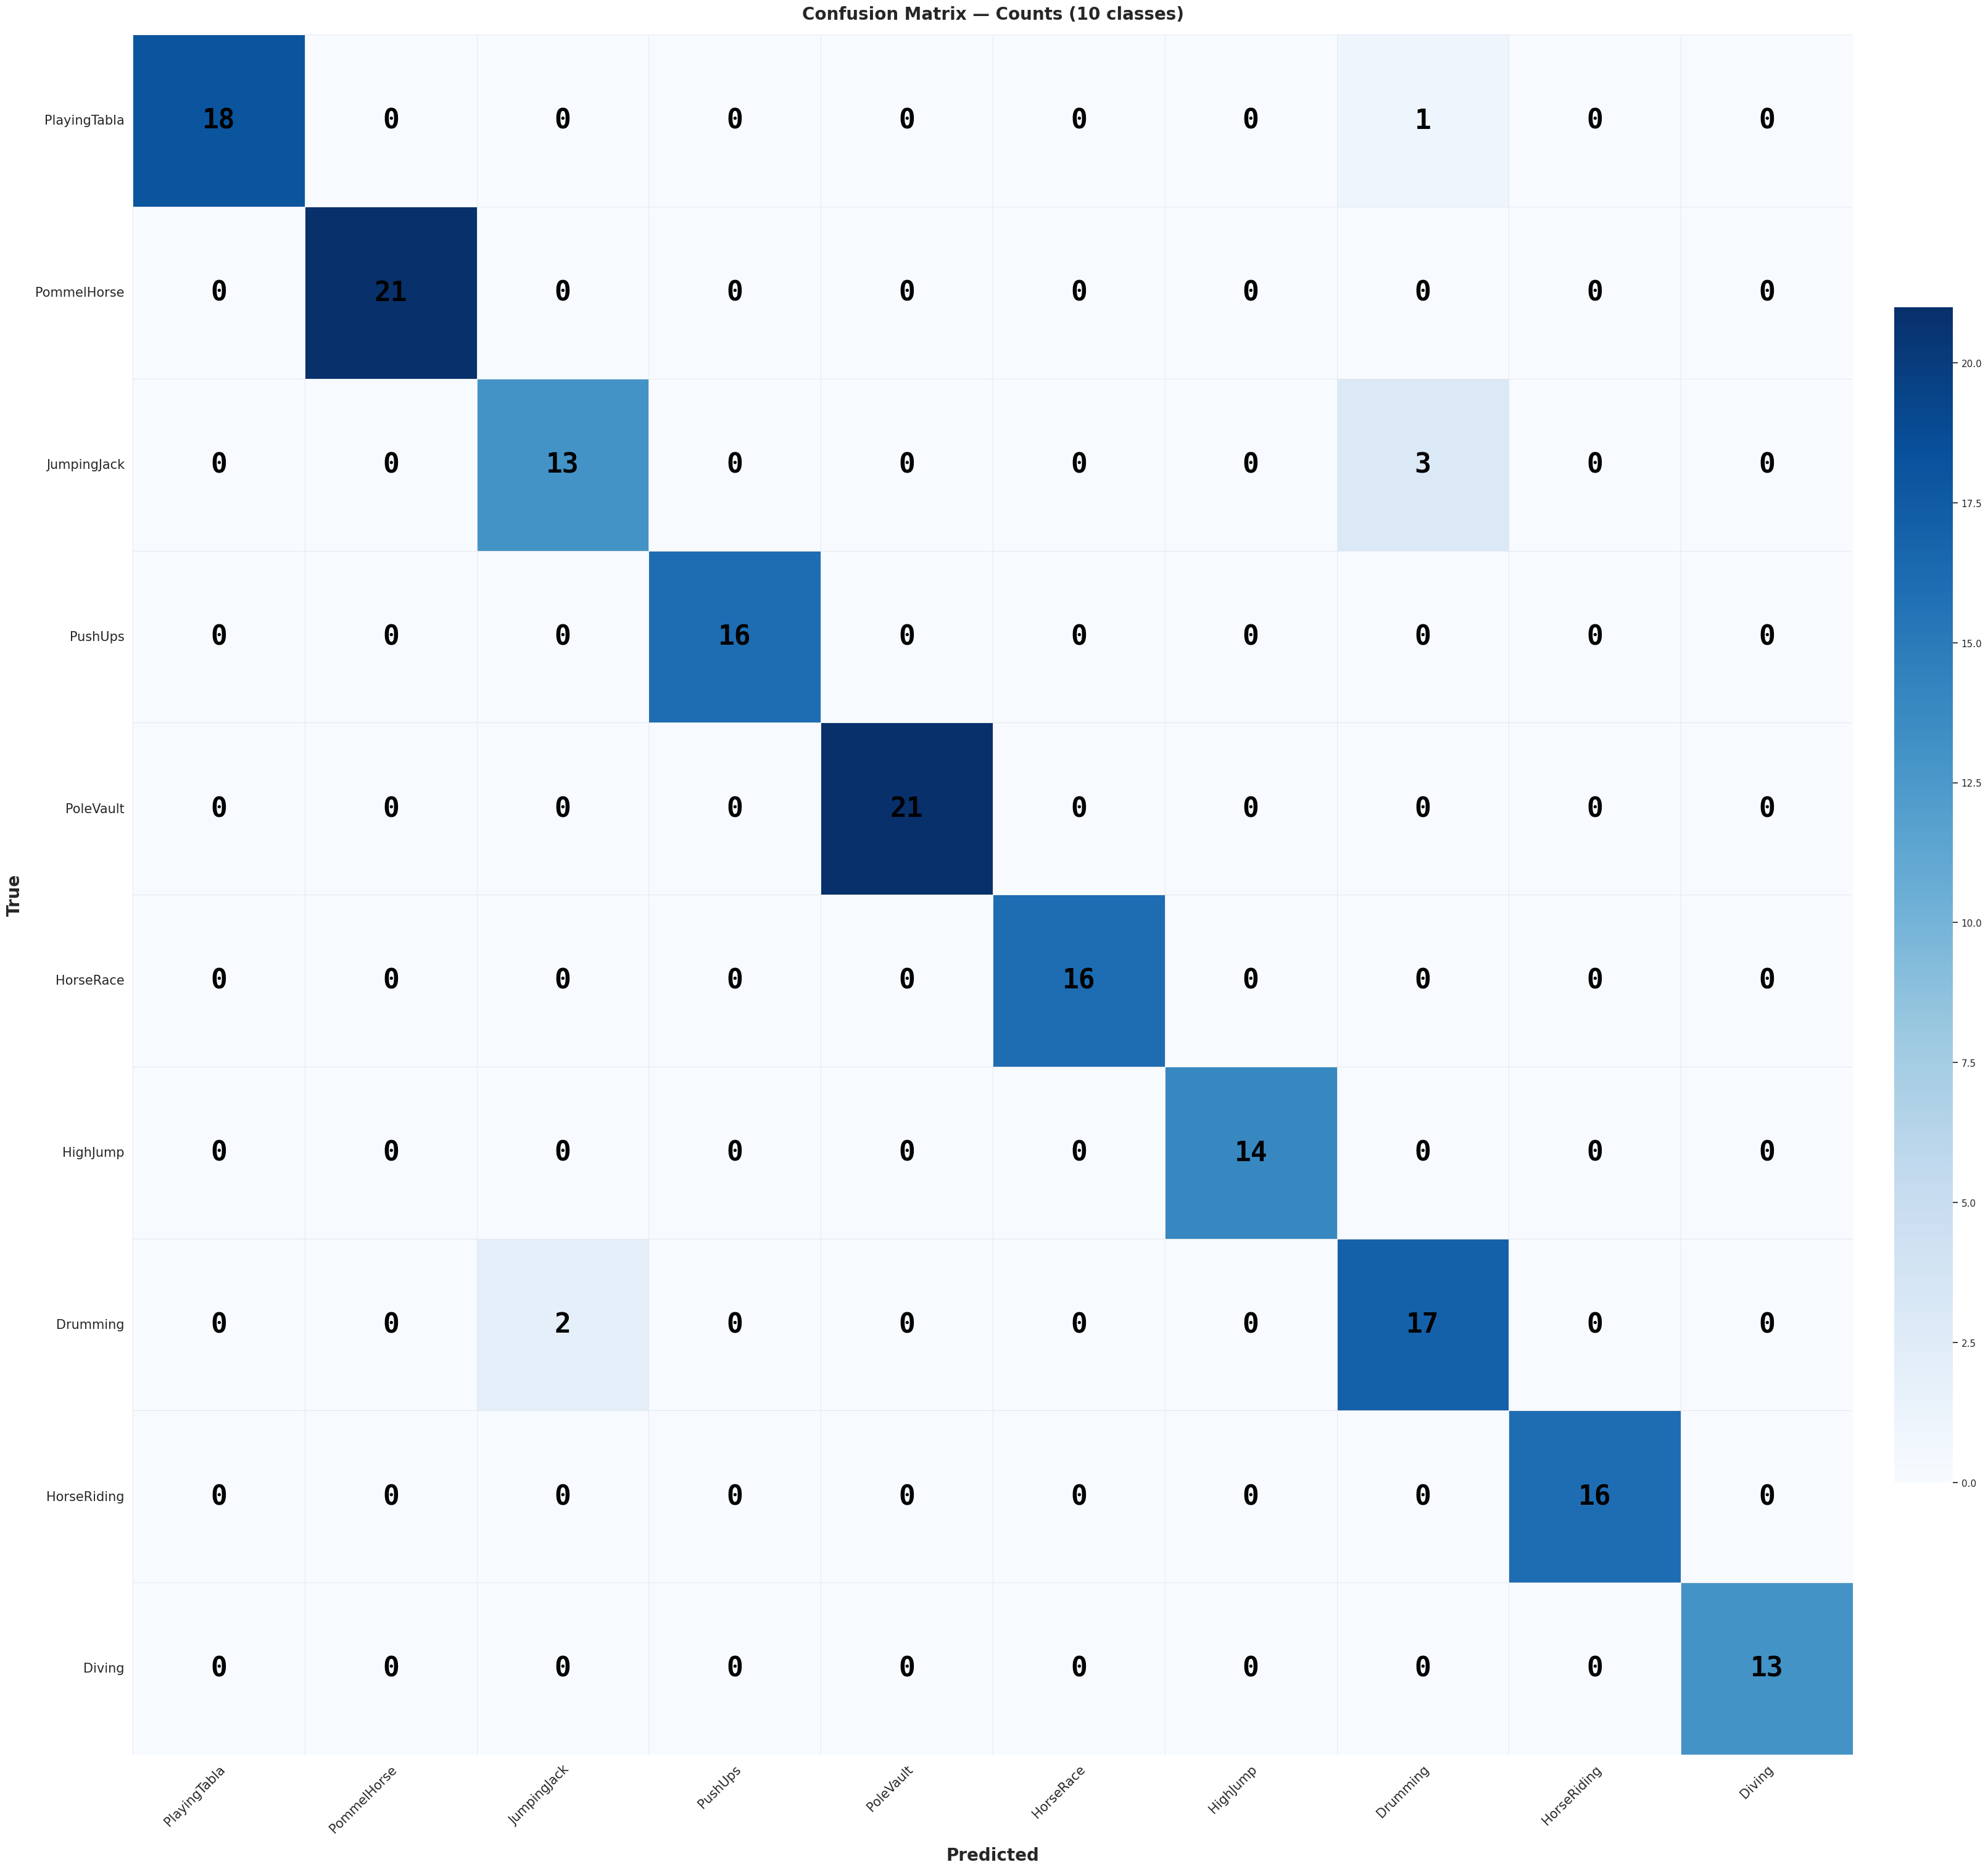

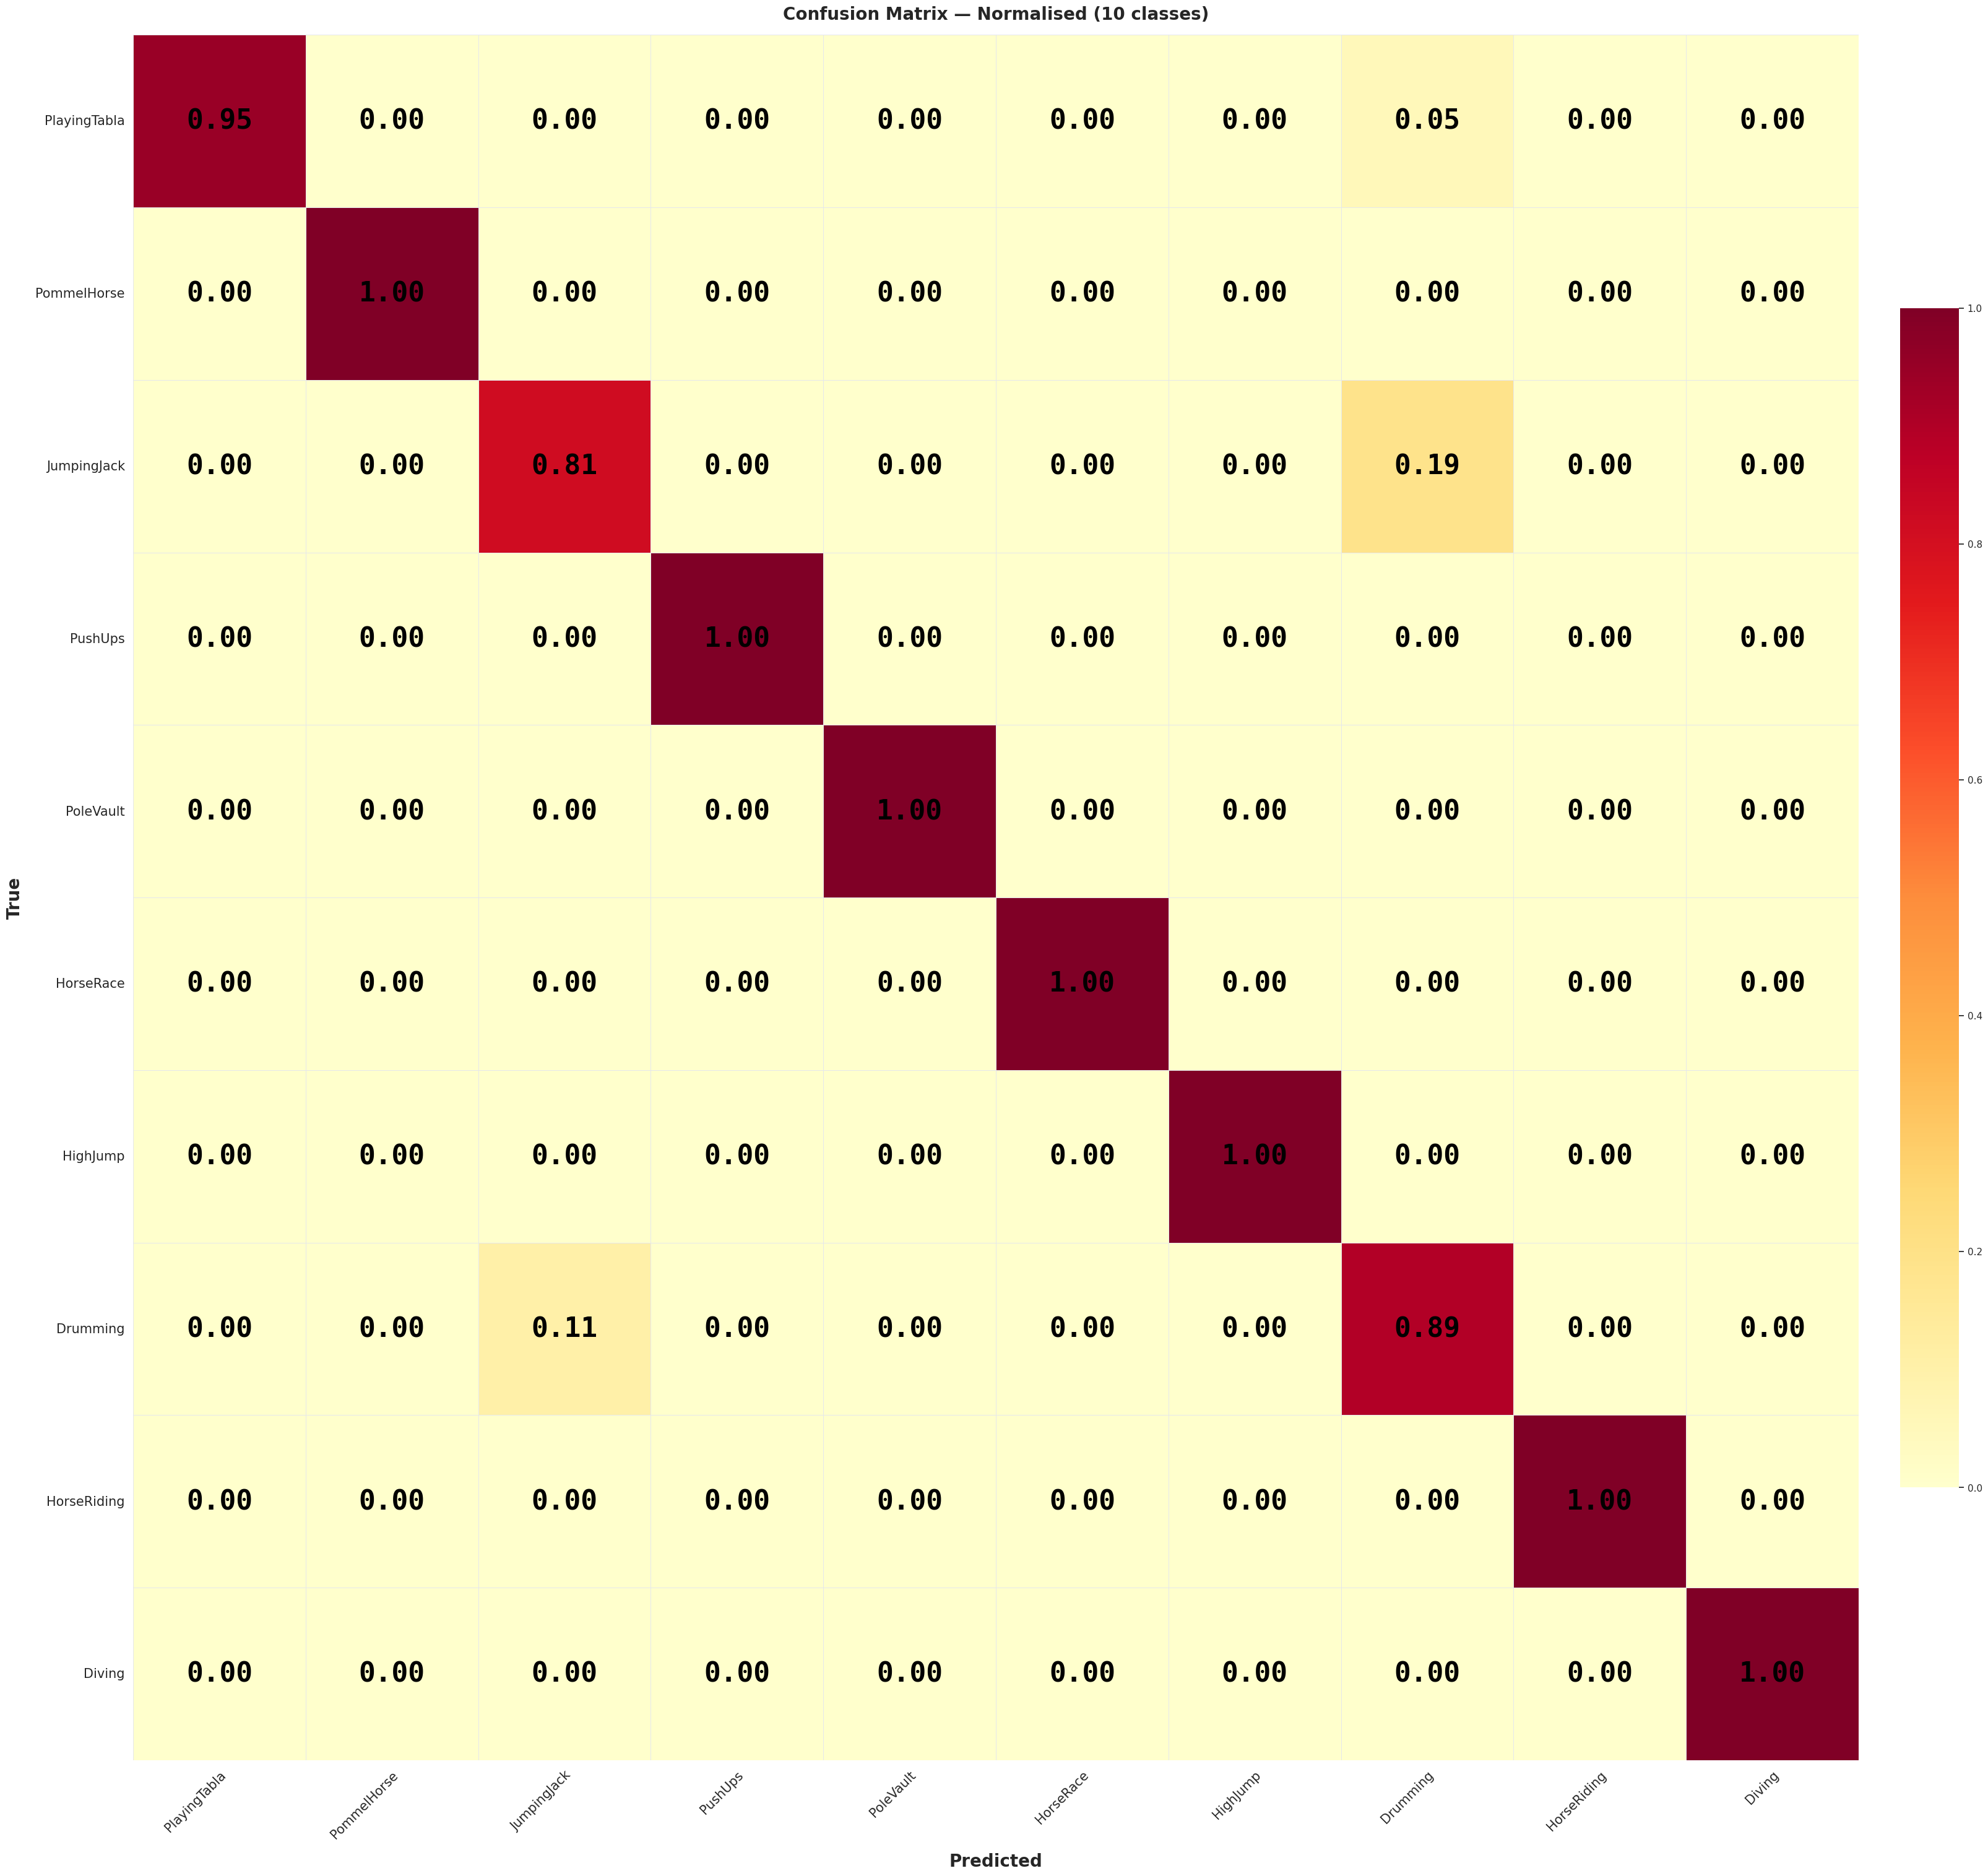

In [35]:
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)

In [36]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9649
  Precision : 0.9664
  Recall    : 0.9649
  F1-Score  : 0.9652

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      0.95      0.97        19
 PommelHorse       1.00      1.00      1.00        21
 JumpingJack       0.87      0.81      0.84        16
     PushUps       1.00      1.00      1.00        16
   PoleVault       1.00      1.00      1.00        21
   HorseRace       1.00      1.00      1.00        16
    HighJump       1.00      1.00      1.00        14
    Drumming       0.81      0.89      0.85        19
 HorseRiding       1.00      1.00      1.00        16
      Diving       1.00      1.00      1.00        13

    accuracy                           0.96       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.96      0.97       171

TOP 5 BEST CLASSES (F1)
  1. Diving                   : 1.0000
  2. HorseRiding        

## **VGG19_BN + LSTM**

In [37]:
model = VGG19BNLSTM().to(device)

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:03<00:00, 181MB/s] 


In [38]:
summary(model, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG19BNLSTM                              [1, 10]                   --
├─Sequential: 1-1                        [16, 512, 7, 7]           --
│    └─Conv2d: 2-1                       [16, 64, 224, 224]        (1,792)
│    └─BatchNorm2d: 2-2                  [16, 64, 224, 224]        (128)
│    └─ReLU: 2-3                         [16, 64, 224, 224]        --
│    └─Conv2d: 2-4                       [16, 64, 224, 224]        (36,928)
│    └─BatchNorm2d: 2-5                  [16, 64, 224, 224]        (128)
│    └─ReLU: 2-6                         [16, 64, 224, 224]        --
│    └─MaxPool2d: 2-7                    [16, 64, 112, 112]        --
│    └─Conv2d: 2-8                       [16, 128, 112, 112]       (73,856)
│    └─BatchNorm2d: 2-9                  [16, 128, 112, 112]       (256)
│    └─ReLU: 2-10                        [16, 128, 112, 112]       --
│    └─Conv2d: 2-11                      [16, 128, 112, 112

In [39]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [40]:
results = fine_tune_model(
    model,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device=device,
    task_offset=0,           # no offset -> standard training on labels 0–9
    task_name="base",
    save_flag=False,
)


Fine-tuning 'base'  |  offset=0  |  epochs=10


  [base] E1/10: 100%|██████████| 249/249 [02:23<00:00,  1.74it/s]


  Epoch   1: Train Loss=1.3137 Acc=0.6177 | Val Loss=0.3528 Acc=0.8909


  [base] E2/10: 100%|██████████| 249/249 [02:22<00:00,  1.75it/s]


  Epoch   2: Train Loss=0.3746 Acc=0.8984 | Val Loss=0.1669 Acc=0.9515


...

  Epoch   8: Train Loss=0.1048 Acc=0.9708 | Val Loss=0.2090 Acc=0.9515


  [base] E9/10: 100%|██████████| 249/249 [02:22<00:00,  1.75it/s]


  Epoch   9: Train Loss=0.0623 Acc=0.9859 | Val Loss=0.1624 Acc=0.9515


  [base] E10/10: 100%|██████████| 249/249 [02:22<00:00,  1.75it/s]


  Epoch  10: Train Loss=0.0625 Acc=0.9779 | Val Loss=0.0974 Acc=0.9758


In [41]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9532


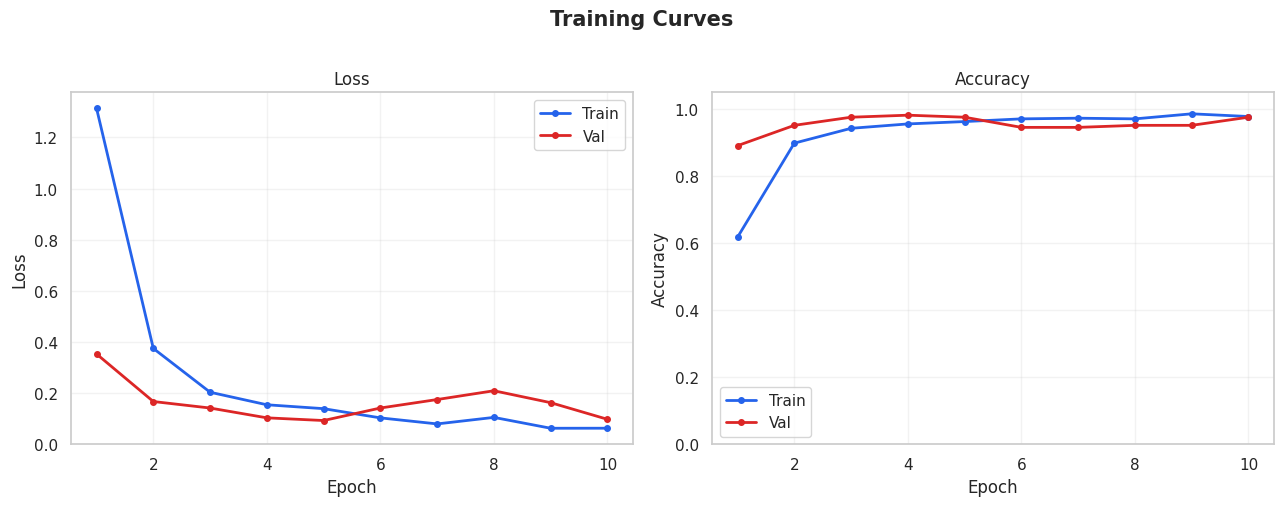

In [42]:
# plot results
plot_training_results(results)

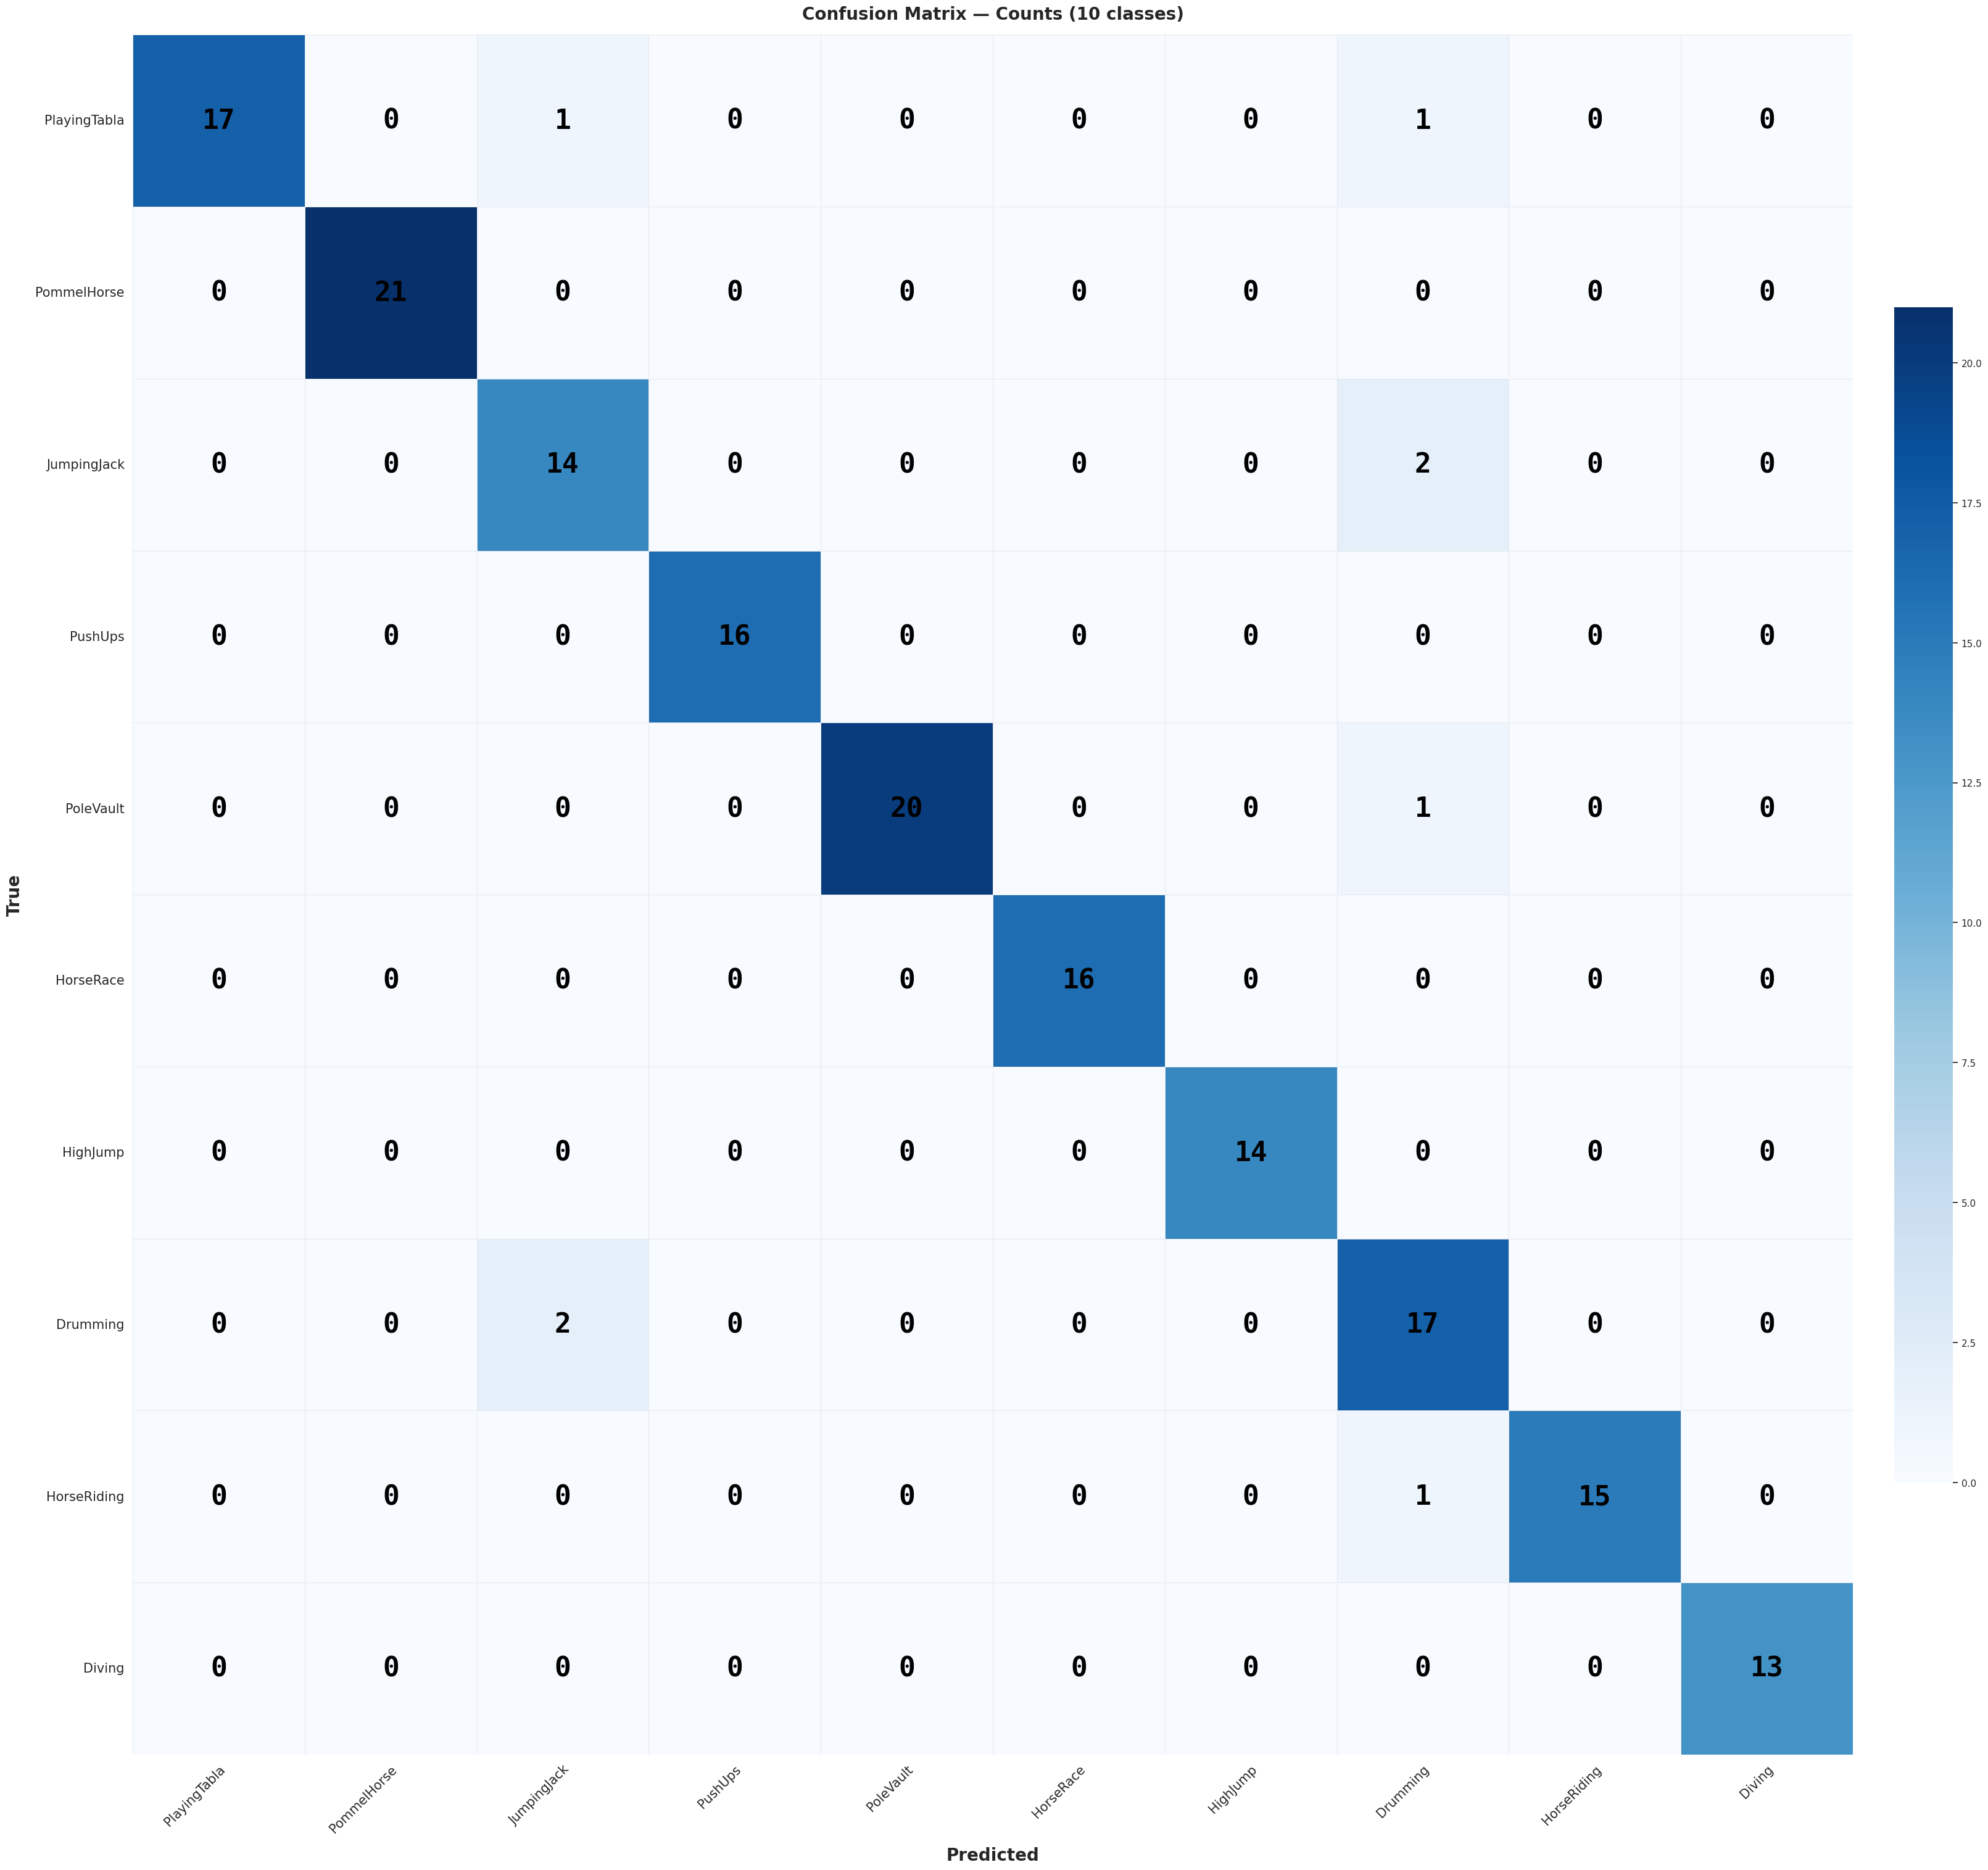

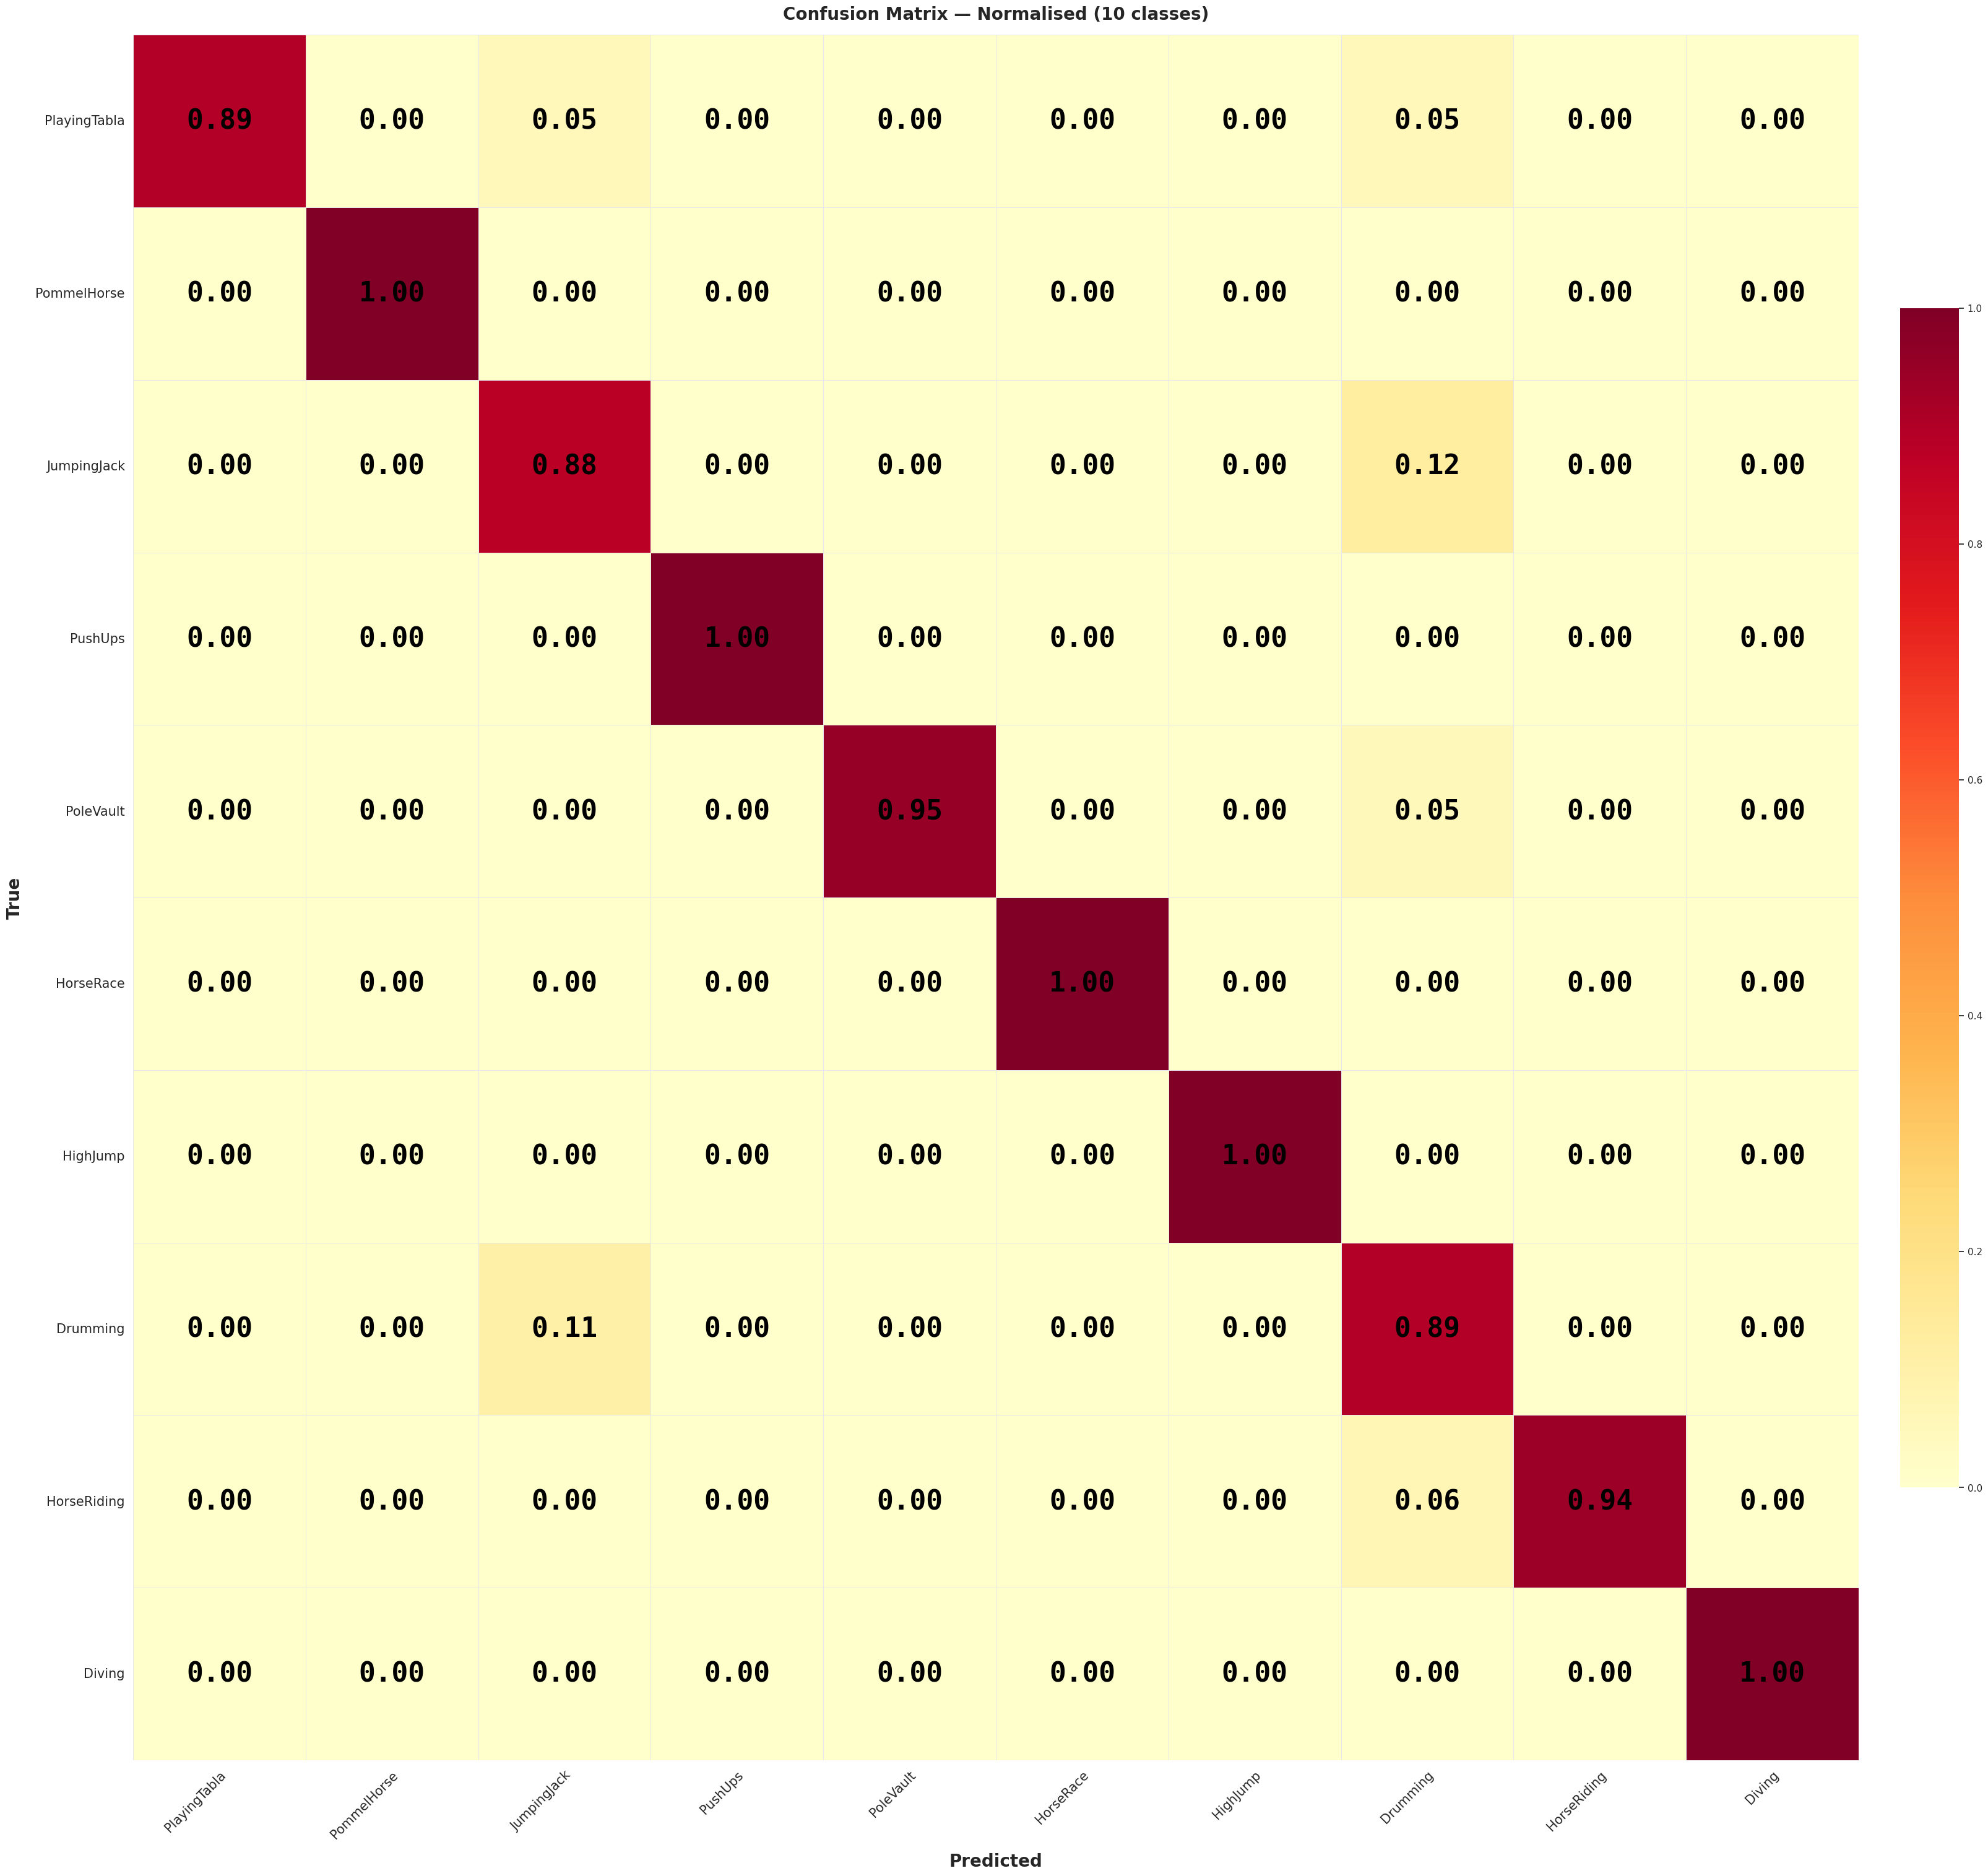

In [43]:
plot_confusion_matrix(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)

In [44]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=10, classes_list=CLASSES_LIST)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9532
  Precision : 0.9582
  Recall    : 0.9532
  F1-Score  : 0.9547

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      0.89      0.94        19
 PommelHorse       1.00      1.00      1.00        21
 JumpingJack       0.82      0.88      0.85        16
     PushUps       1.00      1.00      1.00        16
   PoleVault       1.00      0.95      0.98        21
   HorseRace       1.00      1.00      1.00        16
    HighJump       1.00      1.00      1.00        14
    Drumming       0.77      0.89      0.83        19
 HorseRiding       1.00      0.94      0.97        16
      Diving       1.00      1.00      1.00        13

    accuracy                           0.95       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.95      0.95       171

TOP 5 BEST CLASSES (F1)
  1. Diving                   : 1.0000
  2. HighJump           

## **EXCTRACT FEATRES & SAVE**

In [45]:
# take off classifier weights ('fc')
filtered_checkpoint = {k: v for k, v in checkpoint.items() if not k.startswith('fc.')}

# take only non-classifier layers
model_ResNet50.load_state_dict(filtered_checkpoint, strict=False)

model_ResNet50.eval()
model_ResNet50.to('cuda' if torch.cuda.is_available() else 'cpu')

ResNet50LSTM(
  (resnet): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(

In [46]:
# Paths for saving features
base_path = '/content/drive/MyDrive/apai/resnet50/features'
os.makedirs(base_path, exist_ok=True)

train_features_path = os.path.join(base_path, "train_features.pt")
train_labels_path   = os.path.join(base_path, "train_labels.pt")
val_features_path   = os.path.join(base_path, "val_features.pt")
val_labels_path     = os.path.join(base_path, "val_labels.pt")
test_features_path  = os.path.join(base_path, "test_features.pt")
test_labels_path    = os.path.join(base_path, "test_labels.pt")

print("Features will be saved in:", base_path)

def extract_features(model, clip_tensor):
    batch_size, seq_len, C, H, W = clip_tensor.shape
    clip_tensor = clip_tensor.to(device)
    with torch.no_grad():
        features = model.resnet(clip_tensor.view(batch_size * seq_len, C, H, W))
        features = features.view(batch_size, seq_len, -1)
        lstm_out, _ = model.lstm(features)
        video_features = lstm_out[:, -1, :]  # last timestep
    return video_features.cpu()

def process_dataloader(dataloader, model, features_file, labels_file):
    all_features = []
    all_labels = []
    for clips, labels in dataloader:
        features = extract_features(model, clips)
        all_features.append(features)
        all_labels.append(labels.cpu())
    all_features = torch.cat(all_features, dim=0)
    all_labels   = torch.cat(all_labels, dim=0)
    torch.save(all_features, features_file)
    torch.save(all_labels, labels_file)
    print(f"Saved features to {features_file}")
    print(f"Saved labels to {labels_file}")
    return all_features, all_labels

# exctract features for each train, val, test
train_features, train_labels = process_dataloader(train_loader, model_ResNet50, train_features_path, train_labels_path)
val_features, val_labels     = process_dataloader(val_loader, model_ResNet50, val_features_path, val_labels_path)
test_features, test_labels   = process_dataloader(test_loader, model_ResNet50, test_features_path, test_labels_path)

Features will be saved in: /content/drive/MyDrive/apai/resnet50/features
Saved features to /content/drive/MyDrive/apai/resnet50/features/train_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/train_labels.pt
Saved features to /content/drive/MyDrive/apai/resnet50/features/val_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/val_labels.pt
Saved features to /content/drive/MyDrive/apai/resnet50/features/test_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/test_labels.pt
